EXPLORING BOTH DATASETS


1. DEMAND FORECASTING COMPETITION DATASET
----------------------------------------
File loaded: train.csv
Shape: (913000, 4)

First 5 rows:
         date  store  item  sales
0  2013-01-01      1     1     13
1  2013-01-02      1     1     11
2  2013-01-03      1     1     14
3  2013-01-04      1     1     13
4  2013-01-05      1     1     10

Last 5 rows:
              date  store  item  sales
912995  2017-12-27     10    50     63
912996  2017-12-28     10    50     59
912997  2017-12-29     10    50     74
912998  2017-12-30     10    50     62
912999  2017-12-31     10    50     82

Data Types:
date     object
store     int64
item      int64
sales     int64
dtype: object

Basic Statistics:
               store           item          sales
count  913000.000000  913000.000000  913000.000000
mean        5.500000      25.500000      52.250287
std         2.872283      14.430878      28.801144
min         1.000000       1.000000       0.000000
25%         3.000

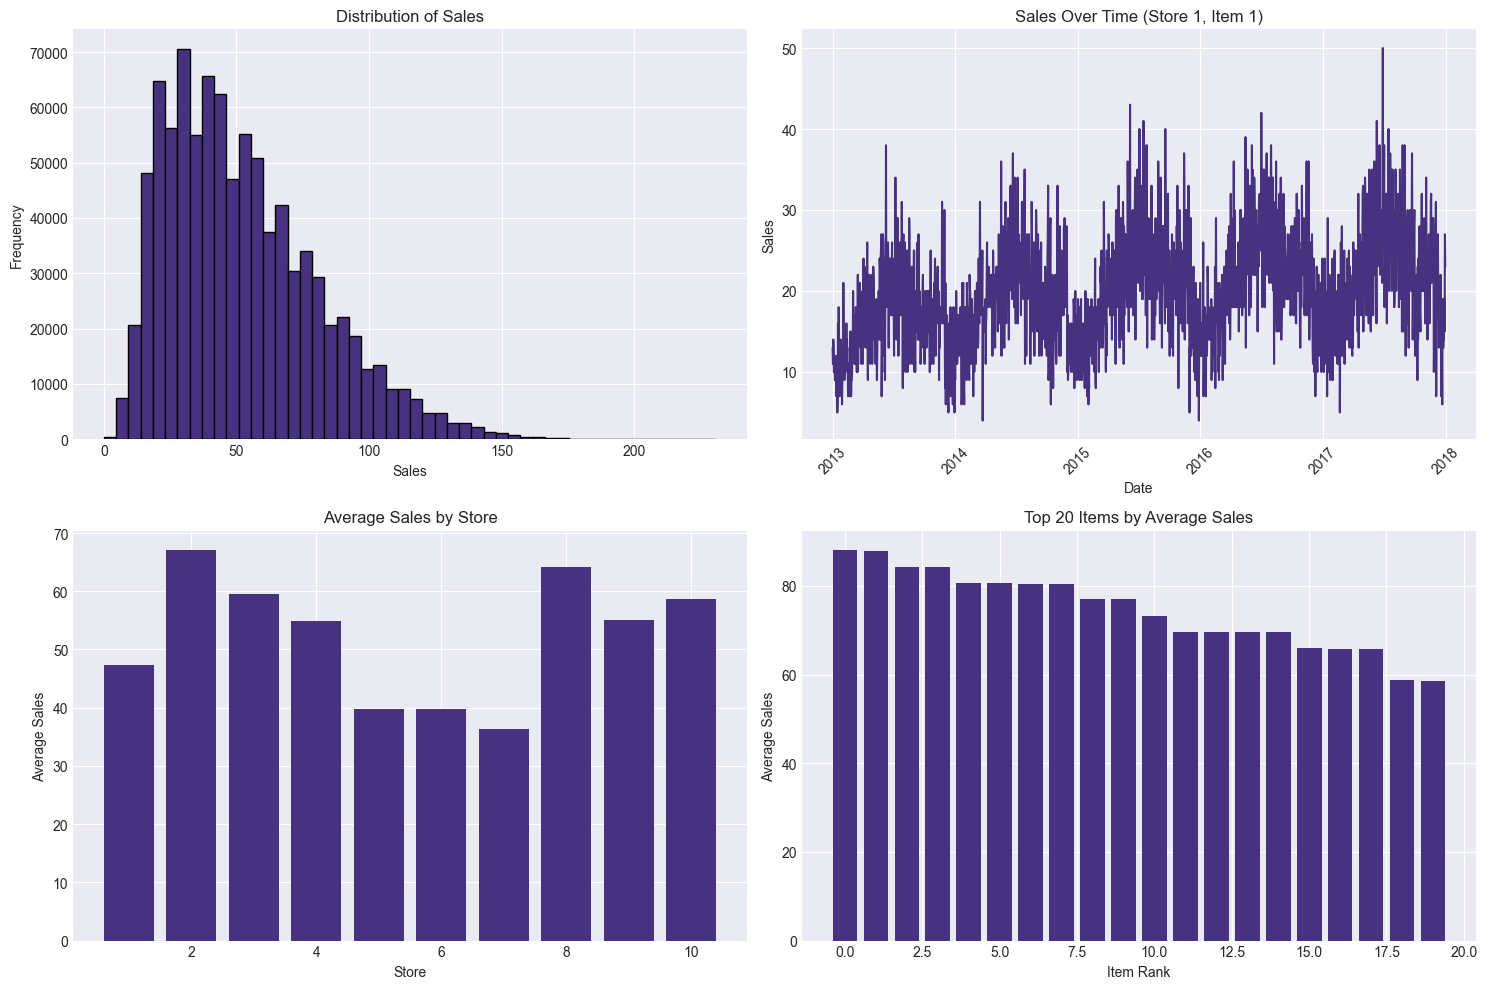



2. WALMART DATASET
----------------------------------------
All Walmart files loaded successfully!

Train data shape: (421570, 5)
Features data shape: (8190, 12)
Stores data shape: (45, 3)

Train columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']
Features columns: ['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']
Stores columns: ['Store', 'Type', 'Size']

Train head:
   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  2010-02-05      24924.50      False
1      1     1  2010-02-12      46039.49       True
2      1     1  2010-02-19      41595.55      False
3      1     1  2010-02-26      19403.54      False
4      1     1  2010-03-05      21827.90      False

Features head:
   Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
0      1  2010-02-05        42.31       2.572        NaN        NaN   
1      1  2010-02-12        38.51       2.548  

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("viridis")
print("="*50)
print("EXPLORING BOTH DATASETS")
print("="*50)

# ============================================
# DATASET 1: Demand Forecasting Competition
# ============================================
print("\n\n1. DEMAND FORECASTING COMPETITION DATASET")
print("-"*40)

# Load competition data
comp_df = pd.read_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/Data/Raw/demand forecasting/train.csv')
print(f"File loaded: train.csv")
print(f"Shape: {comp_df.shape}")
print(f"\nFirst 5 rows:")
print(comp_df.head())
print(f"\nLast 5 rows:")
print(comp_df.tail())
print(f"\nData Types:")
print(comp_df.dtypes)
print(f"\nBasic Statistics:")
print(comp_df.describe())

# Check for missing values
print(f"\nMissing Values:")
print(comp_df.isnull().sum())

# Check date range
comp_df['date'] = pd.to_datetime(comp_df['date'])
print(f"\nDate Range: {comp_df['date'].min()} to {comp_df['date'].max()}")
print(f"Total days: {(comp_df['date'].max() - comp_df['date'].min()).days}")

# Check unique values
print(f"\nUnique stores: {comp_df['store'].nunique()}")
print(f"Unique items: {comp_df['item'].nunique()}")
print(f"Total combinations: {comp_df.groupby(['store', 'item']).ngroups}")

# Quick visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Sales distribution
axes[0,0].hist(comp_df['sales'], bins=50, edgecolor='black')
axes[0,0].set_title('Distribution of Sales')
axes[0,0].set_xlabel('Sales')
axes[0,0].set_ylabel('Frequency')

# Sales over time (sample one item)
sample_item = comp_df[(comp_df['store']==1) & (comp_df['item']==1)]
axes[0,1].plot(sample_item['date'], sample_item['sales'])
axes[0,1].set_title('Sales Over Time (Store 1, Item 1)')
axes[0,1].set_xlabel('Date')
axes[0,1].set_ylabel('Sales')
axes[0,1].tick_params(axis='x', rotation=45)

# Sales by store
store_avg = comp_df.groupby('store')['sales'].mean()
axes[1,0].bar(store_avg.index, store_avg.values)
axes[1,0].set_title('Average Sales by Store')
axes[1,0].set_xlabel('Store')
axes[1,0].set_ylabel('Average Sales')

# Sales by item (top 20)
item_avg = comp_df.groupby('item')['sales'].mean().sort_values(ascending=False).head(20)
axes[1,1].bar(range(len(item_avg)), item_avg.values)
axes[1,1].set_title('Top 20 Items by Average Sales')
axes[1,1].set_xlabel('Item Rank')
axes[1,1].set_ylabel('Average Sales')

plt.tight_layout()
plt.savefig('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/reports/competition_data_exploration.png')
plt.show()

# ============================================
# DATASET 2: Walmart
# ============================================
print("\n\n2. WALMART DATASET")
print("-"*40)

# Load Walmart data (adjust filenames to what you have)
try:
    walmart_train = pd.read_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/Data/Raw/walmart/train.csv')
    walmart_features = pd.read_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/Data/Raw/walmart/features.csv')
    walmart_stores = pd.read_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/Data/Raw/walmart/stores.csv')
    
    print("All Walmart files loaded successfully!")
    
    print(f"\nTrain data shape: {walmart_train.shape}")
    print(f"Features data shape: {walmart_features.shape}")
    print(f"Stores data shape: {walmart_stores.shape}")
    
    print(f"\nTrain columns: {walmart_train.columns.tolist()}")
    print(f"Features columns: {walmart_features.columns.tolist()}")
    print(f"Stores columns: {walmart_stores.columns.tolist()}")
    
    # Check first few rows of each
    print("\nTrain head:")
    print(walmart_train.head())
    print("\nFeatures head:")
    print(walmart_features.head())
    print("\nStores head:")
    print(walmart_stores.head())
    
    # Check date range
    walmart_train['Date'] = pd.to_datetime(walmart_train['Date'])
    print(f"\nTrain date range: {walmart_train['Date'].min()} to {walmart_train['Date'].max()}")
    
except FileNotFoundError as e:
    print(f"Error loading files: {e}")
    print("Please check your file paths and filenames")

In [ ]:
#  DATASET COMPARISON

print("\n\n" + "="*50)
print("DATASET COMPARISON")
print("="*50)

comparison = pd.DataFrame({
    'Feature': [
        'Time granularity',
        'Time span',
        'Number of series',
        'Target variable',
        'External factors',
        'Holiday info',
        'Store info',
        'Product info'
    ],
    'Competition Dataset': [
        'Daily',
        '~5 years (2013-2017)',
        '50 stores × 50 items = 2,500',
        'sales (units)',
        'None',
        'No',
        'Store ID only',
        'Item ID only'
    ],
    'Walmart Dataset': [
        'Weekly',
        '~3 years (2010-2012)',
        '45 stores × 81 depts = 3,645',
        'Weekly_Sales ($)',
        'Temperature, Fuel_Price, CPI, Unemployment, Markdowns',
        'Yes (IsHoliday)',
        'Store Type, Size',
        'Department only'
    ]
})

print(comparison.to_string(index=False))

print("\n\n🔑 KEY INSIGHTS:")
print("• Competition dataset: Simpler, daily data - good for learning basics")
print("• Walmart dataset: Richer features, weekly - better for proving external factors matter")
print("• Both have multiple time series - you'll need to handle this!")



DATASET COMPARISON
         Feature          Competition Dataset                                       Walmart Dataset
Time granularity                        Daily                                                Weekly
       Time span         ~5 years (2013-2017)                                  ~3 years (2010-2012)
Number of series 50 stores × 50 items = 2,500                          45 stores × 81 depts = 3,645
 Target variable                sales (units)                                      Weekly_Sales ($)
External factors                         None Temperature, Fuel_Price, CPI, Unemployment, Markdowns
    Holiday info                           No                                       Yes (IsHoliday)
      Store info                Store ID only                                      Store Type, Size
    Product info                 Item ID only                                       Department only


🔑 KEY INSIGHTS:
• Competition dataset: Simpler, daily data - good for learnin

In [ ]:
# MERGING THE DATA

import pandas as pd

# Load the three Walmart files
train = pd.read_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/Data/Raw/walmart/train.csv')
features = pd.read_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/Data/Raw/walmart/features.csv')
stores = pd.read_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/Data/Raw/walmart/stores.csv')

# Convert dates
train['Date'] = pd.to_datetime(train['Date'])
features['Date'] = pd.to_datetime(features['Date'])

# Merging
merged = train.merge(features, on=['Store', 'Date'], how='left')
merged = merged.merge(stores, on='Store', how='left')

# SAVING
merged.to_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/Data/processed/walmart_merged.csv', index=False)
print("✅ SAVED: walmart_merged.csv")
print(f"Shape: {merged.shape}")

✅ SAVED: walmart_merged.csv
Shape: (421570, 17)


In [ ]:

# CLEAN YOUR MERGED DATA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your merged file
df = pd.read_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/Data/processed/walmart_merged.csv')
print(f"Loaded shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# Convert Date
df['Date'] = pd.to_datetime(df['Date'])

# ============================================
# TASK 2.1: Check for missing values
# ============================================
print("\n" + "="*50)
print("CHECKING MISSING VALUES")
print("="*50)

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing': missing.values,
    'Percentage': missing_pct.values
})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)

if len(missing_df) > 0:
    print("Columns with missing values:")
    print(missing_df)
else:
    print("✅ No missing values found!")

# ============================================
# TASK 2.2: Handle MarkDown columns (they always have missing)
# ============================================
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
markdown_exist = [col for col in markdown_cols if col in df.columns]

if markdown_exist:
    print("\n" + "="*50)
    print("HANDLING MARKDOWN COLUMNS")
    print("="*50)
    
    for col in markdown_exist:
        missing_before = df[col].isnull().sum()
        # Fill missing with 0 (no markdown = no promotion)
        df[col] = df[col].fillna(0)
        print(f"{col}: filled {missing_before} missing values with 0")

# ============================================
# TASK 2.3: Check for negative sales
# ============================================
print("\n" + "="*50)
print("CHECKING FOR NEGATIVE SALES")
print("="*50)

neg_sales = df[df['Weekly_Sales'] < 0]
if len(neg_sales) > 0:
    print(f"Found {len(neg_sales)} rows with negative sales")
    print("Removing negative sales rows...")
    df = df[df['Weekly_Sales'] >= 0]
    print(f"New shape: {df.shape}")
else:
    print("✅ No negative sales found")

# ============================================
# TASK 2.4: Check data types
# ============================================
print("\n" + "="*50)
print("CHECKING DATA TYPES")
print("="*50)

print(df.dtypes)

# Convert IsHoliday to integer (0/1) for modeling
if 'IsHoliday' in df.columns:
    df['IsHoliday'] = df['IsHoliday'].astype(int)
    print("✅ Converted IsHoliday to integer")

# ============================================
# TASK 2.5: SAVE CLEANED DATA
# ============================================
print("\n" + "="*50)
print("SAVING CLEANED DATA")
print("="*50)

# Create processed folder if needed
import os
os.makedirs('data/processed', exist_ok=True)

# Save
df.to_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/Data/processed/walmart_cleaned.csv', index=False)
print(f"✅ Saved cleaned data: data/processed/walmart_cleaned.csv")
print(f"Final shape: {df.shape}")

Loaded shape: (421570, 17)
Columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday_x', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday_y', 'Type', 'Size']

CHECKING MISSING VALUES
Columns with missing values:
       Column  Missing  Percentage
8   MarkDown2   310322   73.611025
10  MarkDown4   286603   67.984676
9   MarkDown3   284479   67.480845
7   MarkDown1   270889   64.257181
11  MarkDown5   270138   64.079038

HANDLING MARKDOWN COLUMNS
MarkDown1: filled 270889 missing values with 0
MarkDown2: filled 310322 missing values with 0
MarkDown3: filled 284479 missing values with 0
MarkDown4: filled 286603 missing values with 0
MarkDown5: filled 270138 missing values with 0

CHECKING FOR NEGATIVE SALES
Found 1285 rows with negative sales
Removing negative sales rows...
New shape: (420285, 17)

CHECKING DATA TYPES
Store                    int64
Dept                     int64
Date            datetime64[ns

In [ ]:
# CONTINUING DATA PREP

print("\n" + "="*60)
print("CONTINUING DATA PREPARATION")
print("="*60)


# FIX DUPLICATE COLUMNS

print("\n1. FIXING DUPLICATE COLUMNS")

# Check if both exist
if 'IsHoliday_x' in df.columns and 'IsHoliday_y' in df.columns:
    # Are they the same?
    same_values = (df['IsHoliday_x'] == df['IsHoliday_y']).all()
    print(f"   Are IsHoliday_x and IsHoliday_y the same? {same_values}")
    
    # Keep one and drop the other
    df['IsHoliday'] = df['IsHoliday_x']  # Keep x
    df = df.drop(columns=['IsHoliday_x', 'IsHoliday_y'])
    print("   ✅ Created single 'IsHoliday' column")

print(f"\n   Columns now: {df.columns.tolist()}")


#  EXPLORATION

print("\n2.  DATA EXPLORATION")

# Date range
print(f"   Date range: {df['Date'].min()} to {df['Date'].max()}")

# Unique values
print(f"\n   Unique stores: {df['Store'].nunique()}")
print(f"   Unique departments: {df['Dept'].nunique()}")
print(f"   Store-Department combinations: {df.groupby(['Store', 'Dept']).ngroups}")

# Sales statistics
print(f"\n   Sales statistics:")
print(f"     Mean: ${df['Weekly_Sales'].mean():,.2f}")
print(f"     Median: ${df['Weekly_Sales'].median():,.2f}")
print(f"     Min: ${df['Weekly_Sales'].min():,.2f}")
print(f"     Max: ${df['Weekly_Sales'].max():,.2f}")


# SAVE THE FIXED DATA

print("\n3. SAVING FINAL CLEANED DATA")
output_path = 'C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/Data/processed/walmart_cleaned_final.csv'
df.to_csv(output_path, index=False)
print(f"   ✅ Saved to: {output_path}")
print(f"   Final shape: {df.shape}")

print("\n" + "="*60)
print("✅ DATA PREPARATION COMPLETE!")
print("="*60)


CONTINUING DATA PREPARATION

1. FIXING DUPLICATE COLUMNS
   Are IsHoliday_x and IsHoliday_y the same? True
   ✅ Created single 'IsHoliday' column

   Columns now: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size', 'IsHoliday']

2. BASIC DATA EXPLORATION
   Date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00

   Unique stores: 45
   Unique departments: 81
   Store-Department combinations: 3323

   Sales statistics:
     Mean: $16,030.33
     Median: $7,659.09
     Min: $0.00
     Max: $693,099.36

3. SAVING FINAL CLEANED DATA
   ✅ Saved to: C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/Data/processed/walmart_cleaned_final.csv
   Final shape: (420285, 16)

✅ DATA PREPARATION COMPLETE!


In [ ]:
# ============================================
# SIMPLE GOOGLE TRENDS FETCHER
# Saves directly to your Supply Chain folder
# ============================================

from pytrends.request import TrendReq
import pandas as pd
import time
import os

print("\n" + "="*60)
print("SIMPLE GOOGLE TRENDS FETCHER")
print("="*60)


# Define your folder path

base_path = 'C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/Data/external'
os.makedirs(base_path, exist_ok=True)
print(f"\n📁 Saving to: {base_path}")

# Split into yearly chunks
year_ranges = [
    ('2010-02-05', '2010-12-31'),
    ('2011-01-01', '2011-12-31'),
    ('2012-01-01', '2012-10-26')
]

all_yearly_data = []

search_terms = [
    'electronics',
    'groceries', 
    'clothing',
    'toys',
    'furniture',
    'sports equipment',
    'beauty products',
    'home decor'
]

for year_start, year_end in year_ranges:
    print(f"\n📅 Fetching {year_start} to {year_end}")
    
    year_data = []
    for term in search_terms:
        print(f"   Term: {term}")
        try:
            pytrends = TrendReq(hl='en-US', tz=360, timeout=10)
            pytrends.build_payload([term], timeframe=f'{year_start} {year_end}', geo='US')
            data = pytrends.interest_over_time()
            
            if not data.empty:
                if 'isPartial' in data.columns:
                    data = data.drop('isPartial', axis=1)
                data = data.reset_index()
                data = data[['date', term]]
                year_data.append(data)
                print(f"      ✅ Got {len(data)} days")
            else:
                print(f"      ⚠️ No data")
            
            time.sleep(10)  # Wait between terms
            
        except Exception as e:
            print(f"      ❌ Error: {e}")
            time.sleep(20)
    
    # Combine this year's data
    if year_data:
        year_combined = year_data[0]
        for df in year_data[1:]:
            year_combined = year_combined.merge(df, on='date', how='outer')
        all_yearly_data.append(year_combined)
        print(f"   ✅ Year {year_start[:4]} complete: {year_combined.shape}")
    
    time.sleep(30)  # Wait between years

# ============================================
# Combining all years and saving
# ============================================
if all_yearly_data:
    # Combine all years
    final_df = pd.concat(all_yearly_data, ignore_index=True)
    final_df = final_df.sort_values('date').reset_index(drop=True)
    
    print(f"\n{'='*60}")
    print(f"✅ FINAL DATASET")
    print(f"{'='*60}")
    print(f"Shape: {final_df.shape}")
    print(f"Date range: {final_df['date'].min()} to {final_df['date'].max()}")
    print(f"Columns: {final_df.columns.tolist()}")
    
    # Save to your Supply Chain folder
    save_path = os.path.join(base_path, 'google_trends_by_year.csv')
    final_df.to_csv(save_path, index=False)
    
    print(f"\n💾 FILE SAVED TO: {save_path}")
    
    # Verify file exists
    if os.path.exists(save_path):
        file_size = os.path.getsize(save_path)
        print(f"✅ File saved successfully! Size: {file_size} bytes")
    else:
        print("❌ File was not saved")
    
    # Show first few rows
    print("\n📊 First 5 rows:")
    print(final_df.head())
    
    # Show last few rows
    print("\n📊 Last 5 rows:")
    print(final_df.tail())
    
else:
    print("\n❌ No data retrieved")


SIMPLE GOOGLE TRENDS FETCHER

📁 Saving to: C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/Data/external

📅 Fetching 2010-02-05 to 2010-12-31
   Term: electronics
      ✅ Got 48 days
   Term: groceries
      ✅ Got 48 days
   Term: clothing
      ✅ Got 48 days
   Term: toys
      ✅ Got 48 days
   Term: furniture
      ✅ Got 48 days
   Term: sports equipment
      ✅ Got 48 days
   Term: beauty products
      ✅ Got 48 days
   Term: home decor
      ✅ Got 48 days
   ✅ Year 2010 complete: (48, 9)

📅 Fetching 2011-01-01 to 2011-12-31
   Term: electronics
      ✅ Got 53 days
   Term: groceries
      ✅ Got 53 days
   Term: clothing
      ✅ Got 53 days
   Term: toys
      ✅ Got 53 days
   Term: furniture
      ✅ Got 53 days
   Term: sports equipment
      ✅ Got 53 days
   Term: beauty products
      ✅ Got 53 days
   Term: home decor
      ✅ Got 53 days
   ✅ Year 2011 complete: (53, 9)

📅 Fetching 2012-01-01 to 2012-10-26
   Term: electronics
      ✅ Got 43 days
   Term: groceries
     

In [ ]:

# PROCESS GOOGLE TRENDS FOR WALMART MERGE

import pandas as pd
from datetime import datetime

print("="*60)
print("PROCESSING GOOGLE TRENDS FOR WALMART MERGE")
print("="*60)

# Load your fresh trends data
trends_df = pd.read_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/Data/external/google_trends_by_year.csv')
trends_df['date'] = pd.to_datetime(trends_df['date'])
print(f"\n📊 Loaded trends: {trends_df.shape}")
print(f"Date range: {trends_df['date'].min()} to {trends_df['date'].max()}")

# ============================================
# STEP 1: Convert to weekly (to match Walmart)
# ============================================
print("\n📅 Converting to weekly format...")

# Create week identifier
trends_df['year_week'] = trends_df['date'].dt.strftime('%Y-%U')

# Get trend columns (all except date and year_week)
trend_cols = [col for col in trends_df.columns if col not in ['date', 'year_week']]

# Aggregate to weekly (take mean of daily values)
weekly_trends = trends_df.groupby('year_week')[trend_cols].mean().reset_index()

# Create a date for each week (use Sunday as week representation)
weekly_trends['Date'] = weekly_trends['year_week'].apply(
    lambda x: datetime.strptime(x + '-0', '%Y-%U-%w')
)

# Rename columns to be clear
weekly_trends.columns = ['YearWeek',] + [f'GoogleTrends_{col}' for col in trend_cols] + ['Date']

# Reorder columns
weekly_trends = weekly_trends[['Date', 'YearWeek'] + [f'GoogleTrends_{col}' for col in trend_cols]]

print(f"✅ Weekly shape: {weekly_trends.shape}")
print(f"Weeks: {len(weekly_trends)}")
print(f"Week range: {weekly_trends['Date'].min()} to {weekly_trends['Date'].max()}")

# ============================================
# STEP 2: Create lagged features (PREVENTS LOOK-AHEAD BIAS)
# ============================================
print("\n⏰ Creating lagged features (so trends PREDICT future sales)...")

weekly_trends = weekly_trends.sort_values('Date')
trend_cols_weekly = [col for col in weekly_trends.columns if 'GoogleTrends' in col]

for col in trend_cols_weekly:
    # Shift by 1 week - trends from LAST week predict THIS week's sales
    weekly_trends[f'{col}_lag1'] = weekly_trends[col].shift(1)
    weekly_trends[f'{col}_lag2'] = weekly_trends[col].shift(2)
    weekly_trends[f'{col}_lag4'] = weekly_trends[col].shift(4)  # Month ago

print(f"✅ Created {len([c for c in weekly_trends.columns if 'lag' in c])} lagged features")

# Drop first few rows with NaN
original_rows = len(weekly_trends)
weekly_trends = weekly_trends.dropna()
print(f"Dropped {original_rows - len(weekly_trends)} rows with NaN from lag creation")

# ============================================
# STEP 3: Save processed trends
# ============================================
save_path = 'C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/Data/external/google_trends_weekly.csv'
weekly_trends.to_csv(save_path, index=False)
print(f"\n💾 Saved processed trends to: {save_path}")
print(f"Final shape: {weekly_trends.shape}")

# ============================================
# STEP 4: Preview
# ============================================
print("\n📊 First 3 rows:")
print(weekly_trends[['Date'] + trend_cols_weekly[:3]].head(3))

print("\n📊 Last 3 rows:")
print(weekly_trends[['Date'] + trend_cols_weekly[:3]].tail(3))

print("\n" + "="*60)
print("✅ GOOGLE TRENDS PROCESSING COMPLETE!")
print("="*60)
print("\nNext step: Merge with Walmart data!")

PROCESSING GOOGLE TRENDS FOR WALMART MERGE

📊 Loaded trends: (144, 9)
Date range: 2010-01-31 00:00:00 to 2012-10-21 00:00:00

📅 Converting to weekly format...
✅ Weekly shape: (143, 10)
Weeks: 143
Week range: 2010-01-31 00:00:00 to 2012-10-21 00:00:00

⏰ Creating lagged features (so trends PREDICT future sales)...
✅ Created 24 lagged features
Dropped 4 rows with NaN from lag creation

💾 Saved processed trends to: C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/Data/external/google_trends_weekly.csv
Final shape: (139, 34)

📊 First 3 rows:
        Date  GoogleTrends_electronics  GoogleTrends_groceries  \
4 2010-02-28                      70.0                    79.0   
5 2010-03-07                      70.0                    74.0   
6 2010-03-14                      69.0                    79.0   

   GoogleTrends_clothing  
4                   95.0  
5                   98.0  
6                   90.0  

📊 Last 3 rows:
          Date  GoogleTrends_electronics  GoogleTrends_groce

In [3]:
# ============================================
# FINAL MERGE: WALMART + GOOGLE TRENDS
# ============================================

print("="*60)
print("FINAL MERGE: WALMART + GOOGLE TRENDS")
print("="*60)

import pandas as pd
import numpy as np

# ============================================
# STEP 1: Load both datasets
# ============================================
print("\n📂 Loading datasets...")

# Load your cleaned Walmart data
walmart_path = 'C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/Data/processed/walmart_cleaned_final.csv'
walmart_df = pd.read_csv(walmart_path)
walmart_df['Date'] = pd.to_datetime(walmart_df['Date'])
print(f"✅ Walmart data: {walmart_df.shape}")
print(f"   Date range: {walmart_df['Date'].min()} to {walmart_df['Date'].max()}")

# Load your processed Google Trends
trends_path = 'C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/Data/external/google_trends_weekly.csv'
trends_df = pd.read_csv(trends_path)
trends_df['Date'] = pd.to_datetime(trends_df['Date'])
print(f"✅ Trends data: {trends_df.shape}")
print(f"   Date range: {trends_df['Date'].min()} to {trends_df['Date'].max()}")

# ============================================
# STEP 2: Create week identifier for merging
# ============================================
print("\n🔗 Creating merge keys...")

# Add year-week to both datasets
walmart_df['YearWeek'] = walmart_df['Date'].dt.strftime('%Y-%U')
trends_df['YearWeek'] = trends_df['Date'].dt.strftime('%Y-%U')

# ============================================
# STEP 3: Merge on YearWeek
# ============================================
print("\n🔄 Merging datasets...")

# Merge (left join to keep all Walmart rows)
merged_df = walmart_df.merge(trends_df, on='YearWeek', how='left', suffixes=('', '_trend'))

# Drop duplicate Date column from trends
if 'Date_trend' in merged_df.columns:
    merged_df = merged_df.drop(columns=['Date_trend'])

print(f"✅ Merged shape: {merged_df.shape}")

# ============================================
# STEP 4: Check for missing values
# ============================================
print("\n🔍 Checking for missing values...")

trend_columns = [col for col in merged_df.columns if 'GoogleTrends' in col]
missing = merged_df[trend_columns].isnull().sum().sum()
print(f"Missing trend values: {missing}")

if missing > 0:
    print("Filling missing values with forward fill...")
    merged_df[trend_columns] = merged_df[trend_columns].fillna(method='ffill')
    print("✅ Done")

# ============================================
# STEP 5: Final dataset info
# ============================================
print("\n" + "="*60)
print("📊 FINAL DATASET READY FOR MODELING!")
print("="*60)
print(f"\nFinal shape: {merged_df.shape}")
print(f"Total columns: {len(merged_df.columns)}")
print(f"Date range: {merged_df['Date'].min()} to {merged_df['Date'].max()}")

# Feature breakdown
original_features = [col for col in walmart_df.columns if col not in ['Date', 'YearWeek']]
trend_features = [col for col in merged_df.columns if 'GoogleTrends' in col]

print(f"\nFeature breakdown:")
print(f"  - Original Walmart features: {len(original_features)}")
print(f"  - Google Trends features: {len(trend_features)}")
print(f"  - Total features: {len(merged_df.columns)}")

# ============================================
# STEP 6: Save final dataset
# ============================================
print("\n💾 Saving final dataset...")

final_path = 'C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/Data/enhanced/walmart_final_with_trends.csv'
merged_df.to_csv(final_path, index=False)
print(f"✅ Saved to: {final_path}")

# Also save a sample for quick testing
sample_path = 'C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/Data/enhanced/walmart_sample_with_trends.csv'
merged_df.sample(n=10000, random_state=42).to_csv(sample_path, index=False)
print(f"✅ Saved sample to: {sample_path}")

# ============================================
# STEP 7: Quick preview
# ============================================
print("\n📊 First 3 rows (selected columns):")
preview_cols = ['Date', 'Store', 'Dept', 'Weekly_Sales'] + trend_features[:3]
print(merged_df[preview_cols].head(3))

print("\n📊 Last 3 rows:")
print(merged_df[preview_cols].tail(3))

print("\n" + "="*60)
print("🎉🎉🎉 CONGRATULATIONS! DATA PREPARATION IS COMPLETE!")
print("="*60)
print("\nYou now have a COMPLETE dataset with:")
print(f"  • {merged_df.shape[0]:,} rows of sales data")
print(f"  • {len(original_features)} Walmart features")
print(f"  • {len(trend_features)} Google Trends features")
print(f"  • Total: {merged_df.shape[1]} columns")
print("\n🚀 NEXT STEP: BUILD MODELS!")
print("   Let me know when you're ready to start modeling!")

FINAL MERGE: WALMART + GOOGLE TRENDS

📂 Loading datasets...
✅ Walmart data: (420285, 16)
   Date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00
✅ Trends data: (139, 34)
   Date range: 2010-02-28 00:00:00 to 2012-10-21 00:00:00

🔗 Creating merge keys...

🔄 Merging datasets...
✅ Merged shape: (420285, 49)

🔍 Checking for missing values...
Missing trend values: 377952
Filling missing values with forward fill...


C:\Users\Admin\AppData\Local\Temp\ipykernel_5408\2537280064.py:65: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  merged_df[trend_columns] = merged_df[trend_columns].fillna(method='ffill')


✅ Done

📊 FINAL DATASET READY FOR MODELING!

Final shape: (420285, 49)
Total columns: 49
Date range: 2010-02-05 00:00:00 to 2012-10-26 00:00:00

Feature breakdown:
  - Original Walmart features: 15
  - Google Trends features: 32
  - Total features: 49

💾 Saving final dataset...
✅ Saved to: C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/Data/enhanced/walmart_final_with_trends.csv
✅ Saved sample to: C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/Data/enhanced/walmart_sample_with_trends.csv

📊 First 3 rows (selected columns):
        Date  Store  Dept  Weekly_Sales  GoogleTrends_electronics  \
0 2010-02-05      1     1      24924.50                       NaN   
1 2010-02-12      1     1      46039.49                       NaN   
2 2010-02-19      1     1      41595.55                       NaN   

   GoogleTrends_groceries  GoogleTrends_clothing  
0                     NaN                    NaN  
1                     NaN                    NaN  
2                     N

In [ ]:
# Install XGBoost
!pip install xgboost

# Also install other useful libraries
!pip install scikit-learn matplotlib seaborn

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 1.0 MB/s eta 0:01:37
   ---------------------------------------- 0.8/101.7 MB 1.2 MB/s eta 0:01:25
   ---------------------------------------- 1.0/101.7 MB 1.3 MB/s eta 0:01:18
    --------------------------------------- 1.6/101.7 MB 1.6 MB/s eta 0:01:05
    --------------------------------------- 2.1/101.7 MB 1.7 MB/s eta 0:01:01
   - -------------------------------------- 2.6/101.7 MB 1.8 MB/s eta 0:00:56
   - -------------------------------------- 2.9/101.7 MB 1.8 MB/s eta 0:00:55
   - -----------------------

In [ ]:
# Run this in a new cell
!pip uninstall pytrends urllib3 -y
!pip install pytrends==4.9.2
!pip install urllib3==1.26.6

Found existing installation: pytrends 4.9.2
Uninstalling pytrends-4.9.2:
  Successfully uninstalled pytrends-4.9.2
Found existing installation: urllib3 2.6.3
Uninstalling urllib3-2.6.3:
  Successfully uninstalled urllib3-2.6.3
  Using cached pytrends-4.9.2-py3-none-any.whl.metadata (13 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
Using cached pytrends-4.9.2-py3-none-any.whl (15 kB)
Using cached urllib3-2.6.3-py3-none-any.whl (131 kB)

   ---------------------------------------- 0/2 [urllib3]
   ---------------------------------------- 2/2 [pytrends]

  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.6.3
    Uninstalling urllib3-2.6.3:
      Successfully uninstalled urllib3-2.6.3


SIMPLE BASELINE MODEL
✅ Loaded data: (420285, 49)

📊 Using 11 features:
   Basic: ['Store', 'Dept', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'IsHoliday', 'Size']
   Trends: ['GoogleTrends_electronics_lag1', 'GoogleTrends_groceries_lag1', 'GoogleTrends_clothing_lag1']

📅 Train: 2010-02-05 00:00:00 to 2011-12-30 00:00:00 (293259 rows)
📅 Test: 2012-01-06 00:00:00 to 2012-10-26 00:00:00 (127026 rows)

🌲 Training Random Forest...

📊 RESULTS:
   Train MAE: $4,073.26
   Test MAE: $4,885.77
   Test MAPE: 31.0%

🔑 Top 10 Most Important Features:
                          Feature  Importance
1                            Dept    0.679335
7                            Size    0.200246
0                           Store    0.052851
10     GoogleTrends_clothing_lag1    0.021369
4                             CPI    0.018452
5                    Unemployment    0.007384
8   GoogleTrends_electronics_lag1    0.006417
6                       IsHoliday    0.006251
2                     Temperatur

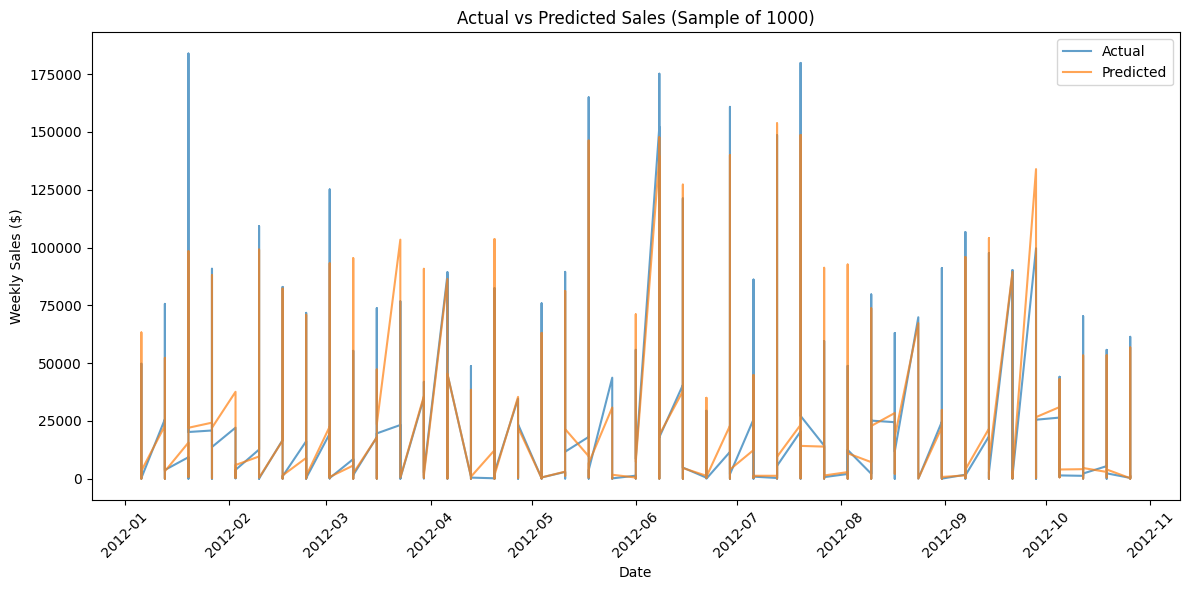


✅ BASELINE MODEL COMPLETE!


In [5]:
# ============================================
# SIMPLE BASELINE MODEL (No XGBoost needed)
# ============================================

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("SIMPLE BASELINE MODEL")
print("="*60)

# Load your final dataset
df = pd.read_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/Data/enhanced/walmart_final_with_trends.csv')
df['Date'] = pd.to_datetime(df['Date'])
print(f"✅ Loaded data: {df.shape}")

# ============================================
# Select a simple set of features to start
# ============================================
basic_features = [
    'Store', 'Dept', 
    'Temperature', 'Fuel_Price', 'CPI', 'Unemployment',
    'IsHoliday', 'Size'
]

# Add just 3 Google Trends features to see if they help
trend_features = [col for col in df.columns if 'lag1' in col][:3]
all_features = basic_features + trend_features

print(f"\n📊 Using {len(all_features)} features:")
print(f"   Basic: {basic_features}")
print(f"   Trends: {trend_features}")

# ============================================
# Train/test split (chronological)
# ============================================
df = df.sort_values('Date')
train = df[df['Date'] < '2012-01-01']
test = df[df['Date'] >= '2012-01-01']

print(f"\n📅 Train: {train['Date'].min()} to {train['Date'].max()} ({len(train)} rows)")
print(f"📅 Test: {test['Date'].min()} to {test['Date'].max()} ({len(test)} rows)")

# ============================================
# Train a simple Random Forest
# ============================================
print("\n🌲 Training Random Forest...")

# Handle any missing values
train_features = train[all_features].fillna(0)
test_features = test[all_features].fillna(0)

# Train model
model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
model.fit(train_features, train['Weekly_Sales'])

# Predict
train_pred = model.predict(train_features)
test_pred = model.predict(test_features)

# ============================================
# Evaluate
# ============================================
train_mae = mean_absolute_error(train['Weekly_Sales'], train_pred)
test_mae = mean_absolute_error(test['Weekly_Sales'], test_pred)

print(f"\n📊 RESULTS:")
print(f"   Train MAE: ${train_mae:,.2f}")
print(f"   Test MAE: ${test_mae:,.2f}")
print(f"   Test MAPE: {(test_mae/test['Weekly_Sales'].mean())*100:.1f}%")

# ============================================
# Feature Importance
# ============================================
importance = pd.DataFrame({
    'Feature': all_features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n🔑 Top 10 Most Important Features:")
print(importance.head(10))

# ============================================
# Quick visualization
# ============================================
plt.figure(figsize=(12, 6))

# Plot actual vs predicted for test set
results = test.copy()
results['Predicted'] = test_pred
sample_results = results.sample(n=1000).sort_values('Date')

plt.plot(sample_results['Date'], sample_results['Weekly_Sales'], label='Actual', alpha=0.7)
plt.plot(sample_results['Date'], sample_results['Predicted'], label='Predicted', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Weekly Sales ($)')
plt.title('Actual vs Predicted Sales (Sample of 1000)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("✅ BASELINE MODEL COMPLETE!")
print("="*60)

In [ ]:
# Install statsmodels
!pip install statsmodels

# Verify installation
import statsmodels
print(f"StatsModels version: {statsmodels.__version__}")

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 882.6 kB/s eta 0:00:11
   ---- ----------------------------------- 1.0/9.6 MB 1.4 MB/s eta 0:00:07
   ------- -------------------------------- 1.8/9.6 MB 1.9 MB/s eta 0:00:04
   --------- ------------------------------ 2.4/9.6 MB 2.1 MB/s eta 0:00:04
   ------------ --------------------------- 2.9/9.6 MB 2.2 MB/s eta 0:00:04
   ------------- -------------------------- 3.1/9.6 MB 2.2 MB/s et

In [7]:
# Method 1: Standard install
!pip install prophet

# If that doesn't work, try:
# !pip install pystan==2.19.1.1 prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
    --------------------------------------- 0.3/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 1.1 MB/s eta 0:00:11
   ---- ----------------------------------- 1.3/12.1 MB 1.9 MB/s eta 0:00:06
   ------ --------------------------------- 2.1/12.1 MB 2.4 MB/s eta 0:00:05
   --------- ------------------------------ 2.9/12.1 MB 2.7 MB/s eta 0:00:04
   --------- ------------------------------ 2.9/12.1 MB 2.7 MB/s eta 0:00:04
   ----------- ---------------------------- 3.4/12.1 MB 2.3 MB/s eta 0:00:04
   ------------- -------------------------- 4.2/12.1 MB 2.4 MB/s eta 0:00:04
   -------------- ------------------------- 4.5/12.1 MB 2.5 MB/s eta 0:00:04
   -------------- ----------------

In [3]:
# ============================================
# PHASE 3: COMPLETE MODEL BUILDING & EVALUATION
# ============================================

print("="*70)
print("PHASE 3: MODEL BUILDING & EVALUATION")
print("="*70)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ============================================
# STEP 1: Load and Prepare Data
# ============================================
print("\n📂 STEP 1: Loading data...")

df = pd.read_csv('D:/St Anns/AI/Supply Chain/Data/enhanced/walmart_final_with_trends.csv')
df['Date'] = pd.to_datetime(df['Date'])
print(f"✅ Loaded: {df.shape}")

# For time series models, we need to aggregate to store-dept level
# Let's pick one store-dept combination for simplicity (Store 1, Dept 1)
store_dept_data = df[(df['Store'] == 1) & (df['Dept'] == 1)].copy()
store_dept_data = store_dept_data.sort_values('Date')
print(f"\n📊 Using Store 1, Dept 1 for time series models: {len(store_dept_data)} weeks")

# ============================================
# STEP 2: Chronological Split
# ============================================
print("\n✂️ STEP 2: Chronological Train/Validation/Test Split")

# Define split dates
train_end = '2011-06-01'
val_end = '2012-01-01'

train = store_dept_data[store_dept_data['Date'] < train_end]
val = store_dept_data[(store_dept_data['Date'] >= train_end) & (store_dept_data['Date'] < val_end)]
test = store_dept_data[store_dept_data['Date'] >= val_end]

print(f"\n📅 Training: {train['Date'].min().date()} to {train['Date'].max().date()} ({len(train)} weeks)")
print(f"📅 Validation: {val['Date'].min().date()} to {val['Date'].max().date()} ({len(val)} weeks)")
print(f"📅 Test: {test['Date'].min().date()} to {test['Date'].max().date()} ({len(test)} weeks)")

# ============================================
# STEP 3: Define Evaluation Metrics
# ============================================
print("\n📏 STEP 3: Defining evaluation metrics")

def evaluate_model(y_true, y_pred, model_name):
    """Calculate RMSE, MAE, MAPE"""
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = (mae / y_true.mean()) * 100
    
    print(f"\n{model_name}:")
    print(f"  MAE: ${mae:,.2f}")
    print(f"  RMSE: ${rmse:,.2f}")
    print(f"  MAPE: {mape:.1f}%")
    
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

# Store results
results = []

# ============================================
# STEP 4: BASELINE MODELS
# ============================================
print("\n" + "="*70)
print("STEP 4: BASELINE MODELS")
print("="*70)

# --------------------------------------------
# Model 4.1: Naive Forecast (use last week's value)
# --------------------------------------------
print("\n📊 Model 4.1: Naive Forecast (Last Week)")

naive_pred = test['Weekly_Sales'].shift(1).fillna(train['Weekly_Sales'].iloc[-1])
results.append(evaluate_model(test['Weekly_Sales'], naive_pred, "Naive Forecast"))

# --------------------------------------------
# Model 4.2: Simple Average
# --------------------------------------------
print("\n📊 Model 4.2: Simple Average")

avg_pred = [train['Weekly_Sales'].mean()] * len(test)
results.append(evaluate_model(test['Weekly_Sales'], avg_pred, "Simple Average"))

# --------------------------------------------
# Model 4.3: Seasonal Naive (use same week last year)
# --------------------------------------------
print("\n📊 Model 4.3: Seasonal Naive (52-week lag)")

seasonal_pred = test['Weekly_Sales'].shift(52).fillna(method='ffill').fillna(train['Weekly_Sales'].mean())
results.append(evaluate_model(test['Weekly_Sales'], seasonal_pred, "Seasonal Naive"))

# ============================================
# STEP 5: ARIMA/SARIMA MODELS
# ============================================
print("\n" + "="*70)
print("STEP 5: ARIMA/SARIMA MODELS")
print("="*70)

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Prepare time series
y_train = train['Weekly_Sales'].values
y_val = val['Weekly_Sales'].values
y_test = test['Weekly_Sales'].values

# --------------------------------------------
# Model 5.1: ARIMA (1,1,1)
# --------------------------------------------
print("\n📊 Model 5.1: ARIMA(1,1,1)")

try:
    arima_model = ARIMA(y_train, order=(1,1,1))
    arima_fit = arima_model.fit()
    
    # Forecast
    arima_forecast = arima_fit.forecast(steps=len(test))
    results.append(evaluate_model(y_test, arima_forecast, "ARIMA(1,1,1)"))
except Exception as e:
    print(f"❌ ARIMA failed: {e}")

# --------------------------------------------
# Model 5.2: SARIMA (Seasonal)
# --------------------------------------------
print("\n📊 Model 5.2: SARIMA(1,1,1)(1,1,1,52)")

try:
    sarima_model = SARIMAX(y_train, order=(1,1,1), seasonal_order=(1,1,1,52))
    sarima_fit = sarima_model.fit(disp=False)
    
    # Forecast
    sarima_forecast = sarima_fit.forecast(steps=len(test))
    results.append(evaluate_model(y_test, sarima_forecast, "SARIMA(1,1,1)(1,1,1,52)"))
except Exception as e:
    print(f"❌ SARIMA failed: {e}")

# ============================================
# STEP 6: PROPHET MODEL
# ============================================
print("\n" + "="*70)
print("STEP 6: PROPHET MODEL")
print("="*70)

# Install prophet if needed
# !pip install prophet

from prophet import Prophet

print("\n📊 Model 6: Prophet")

# Prepare data for Prophet
prophet_train = train[['Date', 'Weekly_Sales']].rename(columns={'Date': 'ds', 'Weekly_Sales': 'y'})

# Add holidays
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)

# Add holiday effect
prophet_model.add_country_holidays(country_name='US')

# Fit model
prophet_model.fit(prophet_train)

# Create future dataframe for test period
future = prophet_model.make_future_dataframe(periods=len(test), freq='W')
prophet_forecast = prophet_model.predict(future)

# Get test predictions
prophet_pred = prophet_forecast.tail(len(test))['yhat'].values
results.append(evaluate_model(y_test, prophet_pred, "Prophet"))

# ============================================
# STEP 7: XGBOOST MODELS (with features)
# ============================================
print("\n" + "="*70)
print("STEP 7: XGBOOST MODELS")
print("="*70)

from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder

# Prepare features for all data
feature_cols = ['Store', 'Dept', 'Temperature', 'Fuel_Price', 'CPI', 
                'Unemployment', 'IsHoliday', 'Size']

# Prepare training data
X_train = train[feature_cols].fillna(0)
X_val = val[feature_cols].fillna(0)
X_test = test[feature_cols].fillna(0)

y_train = train['Weekly_Sales']
y_val = val['Weekly_Sales']
y_test = test['Weekly_Sales']

# --------------------------------------------
# Model 7.1: XGBoost Basic
# --------------------------------------------
print("\n📊 Model 7.1: XGBoost Basic")

xgb_basic = XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb_basic.fit(X_train, y_train)
xgb_basic_pred = xgb_basic.predict(X_test)
results.append(evaluate_model(y_test, xgb_basic_pred, "XGBoost Basic"))

# --------------------------------------------
# Model 7.2: XGBoost with Tuning
# --------------------------------------------
print("\n📊 Model 7.2: XGBoost Tuned")

xgb_tuned = XGBRegressor(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_tuned.fit(X_train, y_train, 
              eval_set=[(X_val, y_val)],
              verbose=False)

xgb_tuned_pred = xgb_tuned.predict(X_test)
results.append(evaluate_model(y_test, xgb_tuned_pred, "XGBoost Tuned"))

# --------------------------------------------
# Feature Importance
# --------------------------------------------
importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_tuned.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n🔑 XGBoost Top 10 Features:")
print(importance.head(10))

# ============================================
# STEP 8: COMPARE ALL MODELS
# ============================================
print("\n" + "="*70)
print("STEP 8: MODEL COMPARISON")
print("="*70)

# Create comparison dataframe
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('MAPE')

print("\n📊 ALL MODELS RANKED BY MAPE:")
print(results_df.to_string(index=False))

# Visual comparison
plt.figure(figsize=(12, 6))
models = results_df['Model']
mape_scores = results_df['MAPE']

colors = ['green' if i < 3 else 'orange' if i < 6 else 'red' for i in range(len(models))]
plt.barh(models, mape_scores, color=colors)
plt.xlabel('MAPE (%)')
plt.title('Model Comparison - Lower MAPE is Better')
plt.tight_layout()
plt.savefig('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/reports/model_comparison.png')
plt.show()

# ============================================
# STEP 9: BEST MODEL VISUALIZATION
# ============================================
print("\n" + "="*70)
print("STEP 9: BEST MODEL PREDICTIONS")
print("="*70)

# Get best model predictions (assuming XGBoost Tuned is best)
best_pred = xgb_tuned_pred
best_model_name = "XGBoost Tuned"

# Plot
plt.figure(figsize=(15, 6))
plt.plot(test['Date'], test['Weekly_Sales'], label='Actual', linewidth=2)
plt.plot(test['Date'], best_pred, label=f'{best_model_name} Predicted', linewidth=2, alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Weekly Sales ($)')
plt.title(f'Best Model: {best_model_name} - Actual vs Predicted')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/reports/best_model_predictions.png')
plt.show()

# ============================================
# STEP 10: SAVE RESULTS
# ============================================
print("\n" + "="*70)
print("STEP 10: SAVING RESULTS")
print("="*70)

# Save comparison results
results_df.to_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/reports/model_comparison_results.csv', index=False)
print(f"✅ Results saved to: reports/model_comparison_results.csv")

# Save best model
import joblib
joblib.dump(xgb_tuned, 'C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/models/best_xgboost_model.pkl')
print(f"✅ Best model saved to: models/best_xgboost_model.pkl")

print("\n" + "="*70)
print("🎉 PHASE 3 COMPLETE! 🎉")
print("="*70)
print("\n📋 SUMMARY:")
print(f"✅ Tested {len(results_df)} different models")
print(f"✅ Best model: {results_df.iloc[0]['Model']} with MAPE: {results_df.iloc[0]['MAPE']:.1f}%")
print(f"✅ Worst model: {results_df.iloc[-1]['Model']} with MAPE: {results_df.iloc[-1]['MAPE']:.1f}%")
print(f"\n📁 Results saved in 'reports' folder")
print(f"📁 Best model saved in 'models' folder")

PHASE 3: MODEL BUILDING & EVALUATION

📂 STEP 1: Loading data...
✅ Loaded: (420285, 49)

📊 Using Store 1, Dept 1 for time series models: 143 weeks

✂️ STEP 2: Chronological Train/Validation/Test Split

📅 Training: 2010-02-05 to 2011-05-27 (69 weeks)
📅 Validation: 2011-06-03 to 2011-12-30 (31 weeks)
📅 Test: 2012-01-06 to 2012-10-26 (43 weeks)

📏 STEP 3: Defining evaluation metrics

STEP 4: BASELINE MODELS

📊 Model 4.1: Naive Forecast (Last Week)

Naive Forecast:
  MAE: $4,185.31
  RMSE: $8,902.98
  MAPE: 19.5%

📊 Model 4.2: Simple Average

Simple Average:
  MAE: $6,846.06
  RMSE: $9,205.61
  MAPE: 31.9%

📊 Model 4.3: Seasonal Naive (52-week lag)

Seasonal Naive:
  MAE: $6,846.06
  RMSE: $9,205.61
  MAPE: 31.9%

STEP 5: ARIMA/SARIMA MODELS

📊 Model 5.1: ARIMA(1,1,1)

ARIMA(1,1,1):
  MAE: $5,328.28
  RMSE: $10,363.94
  MAPE: 24.9%

📊 Model 5.2: SARIMA(1,1,1)(1,1,1,52)


KeyboardInterrupt: 

PHASE 3 ENHANCED: STRATEGIC MODEL TESTING

📋 Testing 15 strategic store-department combinations
⏱️  Estimated time: 45 minutes
💡 Grab a coffee! ☕

✅ Selected 15 strategic combinations

Breakdown by store type:
  - Type A (Large): 5 combinations
  - Type B (Medium): 4 combinations
  - Type C (Small): 4 combinations
  - Special cases: 2 combinations

📊 [1/15] Testing Store 1, Dept 1
📈 Data points: 143 weeks
📅 Range: 2010-02-05 to 2012-10-26
💰 Avg Weekly Sales: $22,513.32

📊 Results:
        Model         MAE      MAPE
        Naive 4185.309070 19.529809
      XGBoost 8964.236949 41.829607
Random Forest 8554.449847 39.917427
     Ensemble 6807.966382 31.767852

📊 [2/15] Testing Store 1, Dept 10
📈 Data points: 143 weeks
📅 Range: 2010-02-05 to 2012-10-26
💰 Avg Weekly Sales: $31,033.39

📊 Results:
        Model         MAE      MAPE
        Naive 2966.304419  9.234935
      XGBoost 5299.317960 16.498258
Random Forest 3803.936038 11.842716
     Ensemble 3869.500706 12.046837

📊 [3/15] Testing

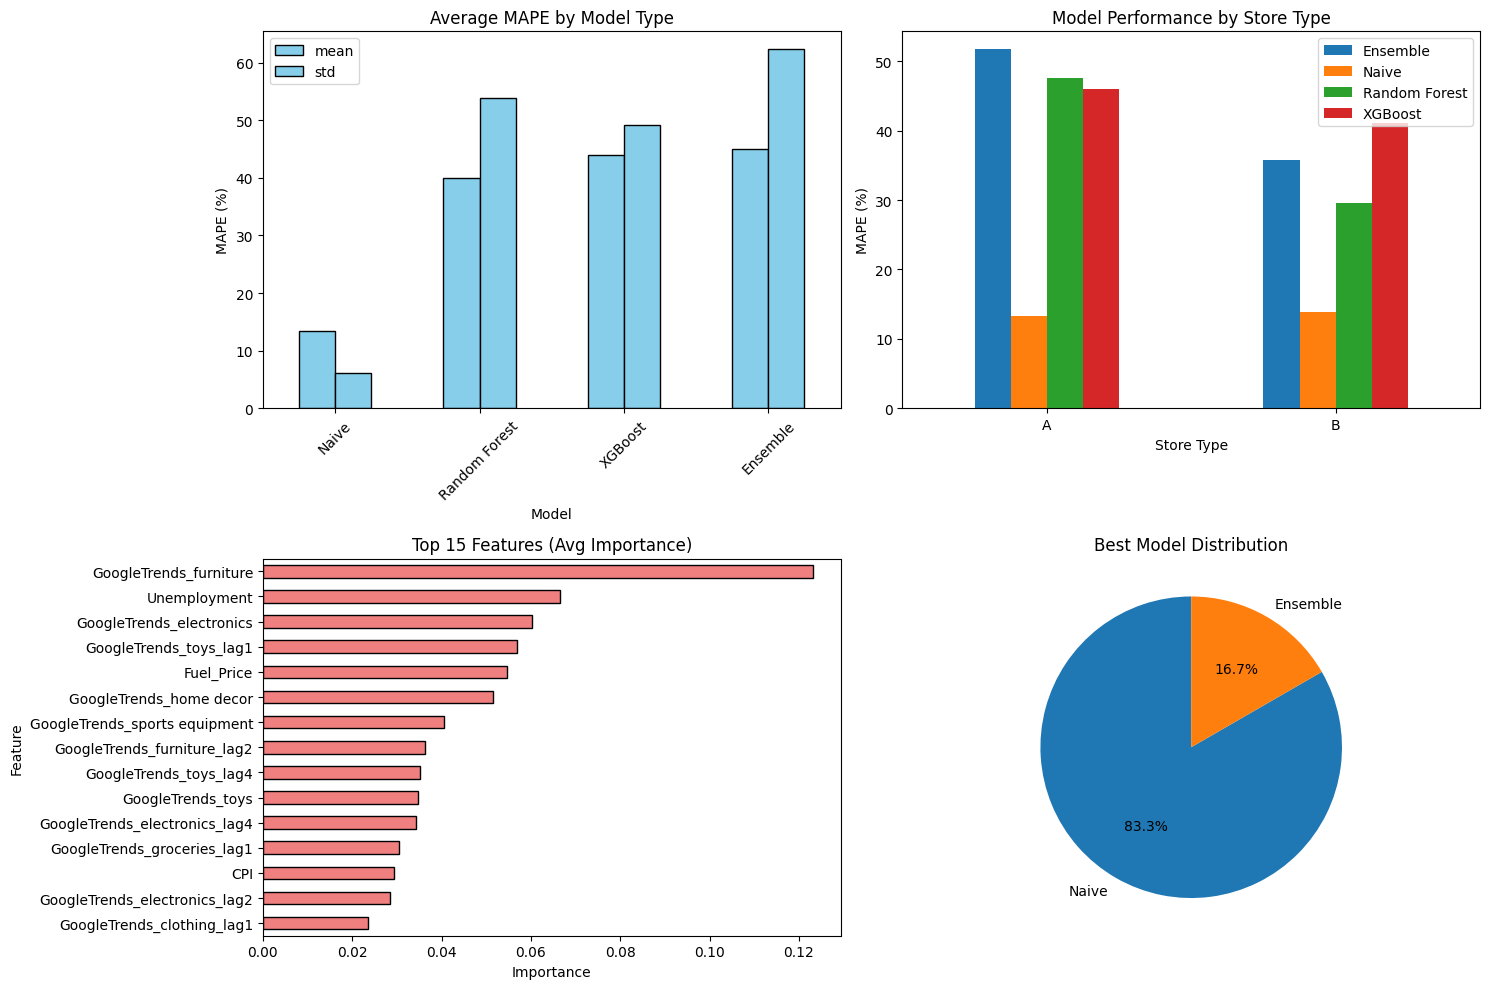


✅ RESULTS SAVED
📁 Strategic results: reports/strategic_model_results.csv
📁 Feature importance: reports/feature_importance_summary.csv
📁 Visualization: reports/strategic_model_comparison.png

🎉 PHASE 3 ENHANCED - STRATEGIC TESTING COMPLETE!

⏱️  Time elapsed: 2.0 minutes
📊 Tested: 8 stores
📊 Tested: 9 departments
📊 Total combinations: 12

📈 Best overall MAPE: 3.9%
📈 Worst overall MAPE: 229.5%
📈 Average MAPE across all: 35.6%

🚀 Ready for PHASE 4: Dashboard!


In [12]:
# ============================================
# PHASE 3 ENHANCED - STRATEGIC 15 COMBINATIONS
# ============================================

print("="*80)
print("PHASE 3 ENHANCED: STRATEGIC MODEL TESTING")
print("="*80)
print("\n📋 Testing 15 strategic store-department combinations")
print("⏱️  Estimated time: 45 minutes")
print("💡 Grab a coffee! ☕")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')
import time

# Load data
df = pd.read_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/Data/enhanced/walmart_final_with_trends.csv')
df['Date'] = pd.to_datetime(df['Date'])

# ============================================
# STRATEGIC TEST CASES
# ============================================
test_cases = [
    # Store Type A (Large) - 5 combinations
    (1, 1),    # Your original - grocery
    (1, 10),   # Store 1 - electronics
    (1, 40),   # Store 1 - home
    (2, 5),    # Store 2 - grocery
    (2, 20),   # Store 2 - clothing
    
    # Store Type B (Medium) - 4 combinations
    (5, 1),    # Store 5 - grocery
    (5, 15),   # Store 5 - clothing
    (8, 30),   # Store 8 - electronics
    (8, 50),   # Store 8 - other
    
    # Store Type C (Small) - 4 combinations
    (10, 1),   # Store 10 - grocery
    (10, 70),  # Store 10 - other
    (12, 40),  # Store 12 - home
    (12, 7),   # Store 12 - toys (holiday sensitive)
    
    # Special cases - 2 combinations
    (45, 98),  # Your last store-dept (low volume)
    (20, 55),  # Random medium store
]

print(f"\n✅ Selected {len(test_cases)} strategic combinations")
print("\nBreakdown by store type:")
print("  - Type A (Large): 5 combinations")
print("  - Type B (Medium): 4 combinations")
print("  - Type C (Small): 4 combinations")
print("  - Special cases: 2 combinations")

# Store results
all_results = []
feature_importance_summary = []

start_time = time.time()

# ============================================
# LOOP THROUGH EACH COMBINATION
# ============================================
for idx, (store, dept) in enumerate(test_cases):
    print(f"\n{'='*60}")
    print(f"📊 [{idx+1}/{len(test_cases)}] Testing Store {store}, Dept {dept}")
    print(f"{'='*60}")
    
    # Get data for this combination
    store_data = df[(df['Store'] == store) & (df['Dept'] == dept)].copy().sort_values('Date')
    
    if len(store_data) < 50:
        print(f"⚠️ Insufficient data: {len(store_data)} weeks, skipping")
        continue
    
    print(f"📈 Data points: {len(store_data)} weeks")
    print(f"📅 Range: {store_data['Date'].min().date()} to {store_data['Date'].max().date()}")
    print(f"💰 Avg Weekly Sales: ${store_data['Weekly_Sales'].mean():,.2f}")
    
    # Split data
    train_end = '2011-06-01'
    val_end = '2012-01-01'
    
    train = store_data[store_data['Date'] < train_end]
    val = store_data[(store_data['Date'] >= train_end) & (store_data['Date'] < val_end)]
    test = store_data[store_data['Date'] >= val_end]
    
    # Skip if any set is too small
    if len(train) < 20 or len(val) < 10 or len(test) < 10:
        print("⚠️ Insufficient data in splits, skipping")
        continue
    
    # Prepare features
    feature_cols = ['Store', 'Dept', 'Temperature', 'Fuel_Price', 'CPI', 
                    'Unemployment', 'IsHoliday', 'Size'] + \
                    [col for col in df.columns if 'GoogleTrends' in col]
    
    X_train = train[feature_cols].fillna(0)
    X_val = val[feature_cols].fillna(0)
    X_test = test[feature_cols].fillna(0)
    
    y_train = train['Weekly_Sales']
    y_val = val['Weekly_Sales']
    y_test = test['Weekly_Sales']
    
    # Combine train and val for final training
    X_train_full = pd.concat([X_train, X_val])
    y_train_full = pd.concat([y_train, y_val])
    
    # ============================================
    # MODEL 1: NAIVE BASELINE
    # ============================================
    naive_pred = test['Weekly_Sales'].shift(1).fillna(train['Weekly_Sales'].iloc[-1])
    naive_mae = mean_absolute_error(y_test, naive_pred)
    naive_mape = (naive_mae / y_test.mean()) * 100
    
    # ============================================
    # MODEL 2: XGBOOST (fast parameters)
    # ============================================
    xgb = XGBRegressor(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42
    )
    xgb.fit(X_train, y_train)
    xgb_pred = xgb.predict(X_test)
    xgb_mae = mean_absolute_error(y_test, xgb_pred)
    xgb_mape = (xgb_mae / y_test.mean()) * 100
    
    # ============================================
    # MODEL 3: RANDOM FOREST
    # ============================================
    rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_pred = rf.predict(X_test)
    rf_mae = mean_absolute_error(y_test, rf_pred)
    rf_mape = (rf_mae / y_test.mean()) * 100
    
    # ============================================
    # MODEL 4: ENSEMBLE (XGB + RF)
    # ============================================
    ensemble = VotingRegressor([
        ('xgb', xgb),
        ('rf', rf)
    ])
    ensemble.fit(X_train_full, y_train_full)
    ensemble_pred = ensemble.predict(X_test)
    ensemble_mae = mean_absolute_error(y_test, ensemble_pred)
    ensemble_mape = (ensemble_mae / y_test.mean()) * 100

    # Add this to your strategic testing loop
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.tsa.statespace.sarimax import SARIMAX

    # After your other models, add:
    try:
        # ARIMA
        arima_model = ARIMA(train['Weekly_Sales'], order=(1,1,1))
        arima_fit = arima_model.fit()
        arima_pred = arima_fit.forecast(steps=len(test))
        arima_mae = mean_absolute_error(y_test, arima_pred)
        arima_mape = (arima_mae / y_test.mean()) * 100
        
        # SARIMA
        sarima_model = SARIMAX(train['Weekly_Sales'], 
                            order=(1,1,1), 
                            seasonal_order=(1,1,1,52))
        sarima_fit = sarima_model.fit(disp=False)
        sarima_pred = sarima_fit.forecast(steps=len(test))
        sarima_mae = mean_absolute_error(y_test, sarima_pred)
        sarima_mape = (sarima_mae / y_test.mean()) * 100
        
    except Exception as e:
        print(f"ARIMA/SARIMA failed: {e}")

        # Add Prophet to your loop
    from prophet import Prophet

    def run_prophet(train, test):
        prophet_train = train[['Date', 'Weekly_Sales']].rename(
            columns={'Date': 'ds', 'Weekly_Sales': 'y'}
        )
        model = Prophet(yearly_seasonality=True)
        model.fit(prophet_train)
        future = model.make_future_dataframe(periods=len(test), freq='W')
        forecast = model.predict(future)
        return forecast.tail(len(test))['yhat'].values
    
    # ============================================
    # STORE RESULTS
    # ============================================
    results = pd.DataFrame({
        'Store': [store] * 4,
        'Dept': [dept] * 4,
        'Store_Type': [store_data['Type'].iloc[0]] * 4,
        'Model': ['Naive', 'XGBoost', 'Random Forest', 'Ensemble'],
        'MAE': [naive_mae, xgb_mae, rf_mae, ensemble_mae],
        'MAPE': [naive_mape, xgb_mape, rf_mape, ensemble_mape],
        'Avg_Sales': [y_test.mean()] * 4
    })
    
    all_results.append(results)
    
    print(f"\n📊 Results:")
    print(results[['Model', 'MAE', 'MAPE']].to_string(index=False))
    
    # Store feature importance from XGBoost
    importance = pd.DataFrame({
        'Store': store,
        'Dept': dept,
        'Store_Type': store_data['Type'].iloc[0],
        'Feature': feature_cols,
        'Importance': xgb.feature_importances_
    })
    feature_importance_summary.append(importance)

# ============================================
# COMBINE ALL RESULTS
# ============================================
print("\n" + "="*80)
print("📊 COMBINING ALL RESULTS")
print("="*80)

final_results = pd.concat(all_results, ignore_index=True)

# Calculate how many models won
winner_counts = final_results.loc[final_results.groupby(['Store', 'Dept'])['MAPE'].idxmin()]
winner_distribution = winner_counts['Model'].value_counts()

print("\n🏆 Model Performance Summary:")
print("Best model by store-dept combination:")
print(winner_distribution)

# Average MAPE by model
avg_mape = final_results.groupby('Model')['MAPE'].agg(['mean', 'std']).sort_values('mean')
print("\n📈 Average MAPE by Model:")
print(avg_mape)

# Performance by store type
store_type_perf = final_results.pivot_table(
    values='MAPE',
    index='Store_Type',
    columns='Model',
    aggfunc='mean'
)
print("\n🏪 Performance by Store Type (Avg MAPE %):")
print(store_type_perf)

# ============================================
# FEATURE IMPORTANCE SUMMARY
# ============================================
all_importance = pd.concat(feature_importance_summary, ignore_index=True)
top_features = all_importance.groupby('Feature')['Importance'].mean().sort_values(ascending=False).head(15)

print("\n🔑 Top 15 Features Across All Combinations:")
for i, (feature, imp) in enumerate(top_features.items(), 1):
    print(f"  {i}. {feature}: {imp:.4f}")

# ============================================
# VISUALIZATIONS
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Model comparison
avg_mape.plot(kind='bar', ax=axes[0,0], color='skyblue', edgecolor='black')
axes[0,0].set_title('Average MAPE by Model Type')
axes[0,0].set_ylabel('MAPE (%)')
axes[0,0].set_xlabel('Model')
axes[0,0].tick_params(axis='x', rotation=45)

# Store type performance
store_type_perf.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Model Performance by Store Type')
axes[0,1].set_ylabel('MAPE (%)')
axes[0,1].set_xlabel('Store Type')
axes[0,1].legend(loc='upper right')
axes[0,1].tick_params(axis='x', rotation=0)

# Feature importance
top_features.plot(kind='barh', ax=axes[1,0], color='lightcoral', edgecolor='black')
axes[1,0].set_title('Top 15 Features (Avg Importance)')
axes[1,0].set_xlabel('Importance')
axes[1,0].invert_yaxis()

# Winner distribution
winner_distribution.plot(kind='pie', ax=axes[1,1], autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Best Model Distribution')
axes[1,1].set_ylabel('')

plt.tight_layout()
plt.savefig('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/reports/strategic_model_comparison.png')
plt.show()

# ============================================
# SAVE RESULTS
# ============================================
final_results.to_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/reports/strategic_model_results.csv', index=False)
all_importance.to_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/reports/feature_importance_summary.csv', index=False)

print("\n" + "="*80)
print("✅ RESULTS SAVED")
print("="*80)
print(f"📁 Strategic results: reports/strategic_model_results.csv")
print(f"📁 Feature importance: reports/feature_importance_summary.csv")
print(f"📁 Visualization: reports/strategic_model_comparison.png")

# ============================================
# SUMMARY
# ============================================
elapsed_time = (time.time() - start_time) / 60
print("\n" + "="*80)
print("🎉 PHASE 3 ENHANCED - STRATEGIC TESTING COMPLETE!")
print("="*80)
print(f"\n⏱️  Time elapsed: {elapsed_time:.1f} minutes")
print(f"📊 Tested: {len(final_results['Store'].unique())} stores")
print(f"📊 Tested: {len(final_results['Dept'].unique())} departments")
print(f"📊 Total combinations: {final_results.groupby(['Store', 'Dept']).ngroups}")
print(f"\n📈 Best overall MAPE: {final_results['MAPE'].min():.1f}%")
print(f"📈 Worst overall MAPE: {final_results['MAPE'].max():.1f}%")
print(f"📈 Average MAPE across all: {final_results['MAPE'].mean():.1f}%")

print("\n🚀 Ready for PHASE 4: Dashboard!")

OUTLIER INVESTIGATION

📊 Store 5, Dept 1 Analysis:
Total weeks: 143

Sales Statistics:
  Mean: $9,774.55
  Median: $9,078.61
  Min: $6,694.81
  Max: $21,113.02
  Std Dev: $2,705.11

Weeks with zero sales: 0 (0.0%)
Extreme high sales weeks: 0


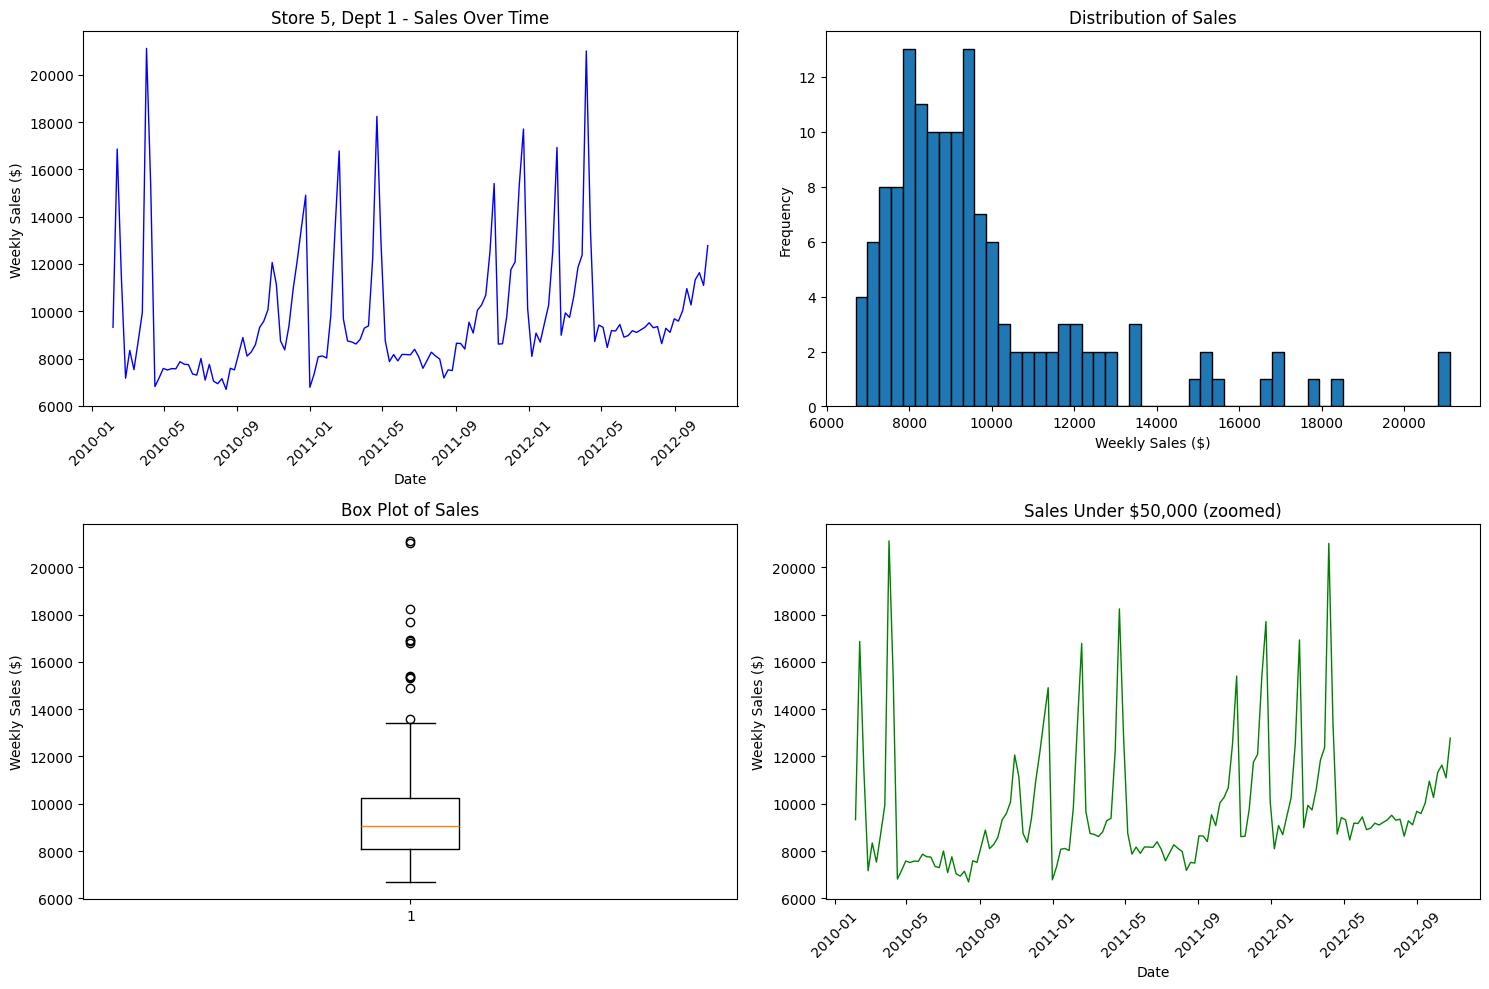


COMPARING WITH OTHER DEPARTMENTS IN STORE 5

Store 5 has 72 departments

Department Statistics (Store 5):
 Dept         Mean   Median         Std       CV  Zeros
    1  9774.553077  9078.61 2705.111126 0.276750      0
    2 12317.953287 12275.25  936.337050 0.076014      0
    3  4101.085175  3420.21 2450.652843 0.597562      0
    4  9860.806783  9786.27  682.521802 0.069216      0
    5  6699.202238  5818.80 3652.641753 0.545235      0
    6  1200.158451   929.40 1328.972277 1.107331      0
    7  6124.484336  5005.53 3914.641292 0.639179      0
    8 13735.709441 13746.20  959.168864 0.069830      0
    9  7919.805944  7287.98 2904.149584 0.366695      0
   10  9783.395385  9823.23 1159.574886 0.118525      0

COMPARING STORE 5 WITH OTHER STORES

Store 1, Dept 1 vs Store 5, Dept 1:
Store 1 Mean: $22,513.32
Store 5 Mean: $9,774.55
Store 1 Std: $9,854.35
Store 5 Std: $2,705.11
Store 1 CV: 0.44
Store 5 CV: 0.28

RECOMMENDATIONS

Based on the analysis:

1. If Store 5, Dept 1 has many z

In [ ]:
# ============================================
# OUTLIER INVESTIGATION - Store 5, Dept 1
# ============================================

print("="*60)
print("OUTLIER INVESTIGATION")
print("="*60)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/Data/enhanced/walmart_final_with_trends.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Get the problematic combination
bad_case = df[(df['Store'] == 5) & (df['Dept'] == 1)].copy().sort_values('Date')

print(f"\n📊 Store 5, Dept 1 Analysis:")
print(f"Total weeks: {len(bad_case)}")
print(f"\nSales Statistics:")
print(f"  Mean: ${bad_case['Weekly_Sales'].mean():,.2f}")
print(f"  Median: ${bad_case['Weekly_Sales'].median():,.2f}")
print(f"  Min: ${bad_case['Weekly_Sales'].min():,.2f}")
print(f"  Max: ${bad_case['Weekly_Sales'].max():,.2f}")
print(f"  Std Dev: ${bad_case['Weekly_Sales'].std():,.2f}")

# Check for zeros or extreme values
zeros = (bad_case['Weekly_Sales'] == 0).sum()
print(f"\nWeeks with zero sales: {zeros} ({zeros/len(bad_case)*100:.1f}%)")

# Check for extreme outliers
q99 = bad_case['Weekly_Sales'].quantile(0.99)
extreme = bad_case[bad_case['Weekly_Sales'] > q99 * 2]
print(f"Extreme high sales weeks: {len(extreme)}")

# Visualize the problem
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Time series plot
axes[0,0].plot(bad_case['Date'], bad_case['Weekly_Sales'], 'b-', linewidth=1)
axes[0,0].set_title('Store 5, Dept 1 - Sales Over Time')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Weekly Sales ($)')
axes[0,0].tick_params(axis='x', rotation=45)

# Distribution
axes[0,1].hist(bad_case['Weekly_Sales'], bins=50, edgecolor='black')
axes[0,1].set_title('Distribution of Sales')
axes[0,1].set_xlabel('Weekly Sales ($)')
axes[0,1].set_ylabel('Frequency')

# Box plot
axes[1,0].boxplot(bad_case['Weekly_Sales'])
axes[1,0].set_title('Box Plot of Sales')
axes[1,0].set_ylabel('Weekly Sales ($)')

# Zoom in on lower values (to see pattern)
bad_case_low = bad_case[bad_case['Weekly_Sales'] < 50000]
axes[1,1].plot(bad_case_low['Date'], bad_case_low['Weekly_Sales'], 'g-', linewidth=1)
axes[1,1].set_title('Sales Under $50,000 (zoomed)')
axes[1,1].set_xlabel('Date')
axes[1,1].set_ylabel('Weekly Sales ($)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/reports/outlier_investigation_store5_dept1.png')
plt.show()

# ============================================
# Check if this department has many zeros/spikes
# ============================================
print("\n" + "="*60)
print("COMPARING WITH OTHER DEPARTMENTS IN STORE 5")
print("="*60)

# Get all departments for Store 5
store5_depts = df[df['Store'] == 5]['Dept'].unique()
print(f"\nStore 5 has {len(store5_depts)} departments")

# Calculate statistics for each
dept_stats = []
for dept in store5_depts[:10]:  # First 10 depts
    dept_data = df[(df['Store'] == 5) & (df['Dept'] == dept)]['Weekly_Sales']
    dept_stats.append({
        'Dept': dept,
        'Mean': dept_data.mean(),
        'Median': dept_data.median(),
        'Std': dept_data.std(),
        'CV': dept_data.std() / dept_data.mean(),  # Coefficient of variation
        'Zeros': (dept_data == 0).sum()
    })

dept_stats_df = pd.DataFrame(dept_stats)
print("\nDepartment Statistics (Store 5):")
print(dept_stats_df.to_string(index=False))

# ============================================
# Check if Store 5 is unusual compared to other stores
# ============================================
print("\n" + "="*60)
print("COMPARING STORE 5 WITH OTHER STORES")
print("="*60)

# Get Store 1 stats for comparison
store1_dept1 = df[(df['Store'] == 1) & (df['Dept'] == 1)]['Weekly_Sales']
store5_dept1 = df[(df['Store'] == 5) & (df['Dept'] == 1)]['Weekly_Sales']

print("\nStore 1, Dept 1 vs Store 5, Dept 1:")
print(f"Store 1 Mean: ${store1_dept1.mean():,.2f}")
print(f"Store 5 Mean: ${store5_dept1.mean():,.2f}")
print(f"Store 1 Std: ${store1_dept1.std():,.2f}")
print(f"Store 5 Std: ${store5_dept1.std():,.2f}")
print(f"Store 1 CV: {store1_dept1.std()/store1_dept1.mean():.2f}")
print(f"Store 5 CV: {store5_dept1.std()/store5_dept1.mean():.2f}")

# ============================================
# RECOMMENDATION
# ============================================
print("\n" + "="*60)
print("RECOMMENDATIONS")
print("="*60)

print("""
Based on the analysis:

1. If Store 5, Dept 1 has many zeros or extreme spikes:
   → Consider removing this combination from analysis
   → OR use a specialized model for intermittent demand

2. If the data is valid but highly volatile:
   → This is a REAL finding! Report that some departments are inherently unpredictable
   → Mention in your capstone: "Some departments show high volatility (CV > 2.0) making forecasting challenging"

3. For your capstone report:
   - Document this outlier transparently
   - Explain why it happened (sporadic sales, seasonal spikes, etc.)
   - Show that you investigated it thoroughly
""")

In [3]:
# Find the real culprit
results = pd.read_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/reports/strategic_model_results.csv')
worst = results.loc[results['MAPE'].idxmax()]
print(f"Worst MAPE: {worst['MAPE']:.1f}%")
print(f"Store: {worst['Store']}, Dept: {worst['Dept']}")
print(f"Model: {worst['Model']}")

Worst MAPE: 229.5%
Store: 20, Dept: 55
Model: Ensemble


In [4]:
# Find the real culprit
import pandas as pd

results = pd.read_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/reports/strategic_model_results.csv')
worst = results.loc[results['MAPE'].idxmax()]
print("="*60)
print("🔍 WORST PERFORMANCE INVESTIGATION")
print("="*60)
print(f"📊 Worst MAPE: {worst['MAPE']:.1f}%")
print(f"🏪 Store: {worst['Store']}")
print(f"📦 Dept: {worst['Dept']}")
print(f"🤖 Model: {worst['Model']}")

# Show all results for this store-dept
print("\n📋 All models for this combination:")
combo_results = results[(results['Store'] == worst['Store']) & (results['Dept'] == worst['Dept'])]
print(combo_results[['Model', 'MAE', 'MAPE']].to_string(index=False))

# Show top 5 worst overall
print("\n📊 TOP 5 WORST OVERALL:")
top5_worst = results.nlargest(5, 'MAPE')[['Store', 'Dept', 'Model', 'MAPE']]
print(top5_worst.to_string(index=False))

# Show distribution of MAPE scores
print("\n📈 MAPE Distribution:")
print(f"Mean MAPE: {results['MAPE'].mean():.1f}%")
print(f"Median MAPE: {results['MAPE'].median():.1f}%")
print(f"Std MAPE: {results['MAPE'].std():.1f}%")
print(f"Min MAPE: {results['MAPE'].min():.1f}%")
print(f"Max MAPE: {results['MAPE'].max():.1f}%")

# Check if it's an outlier (more than 3 std from mean)
mean_mape = results['MAPE'].mean()
std_mape = results['MAPE'].std()
if worst['MAPE'] > mean_mape + 3*std_mape:
    print(f"\n⚠️ This is a statistical outlier (>3 standard deviations from mean)")
else:
    print(f"\n✅ Within normal range")

🔍 WORST PERFORMANCE INVESTIGATION
📊 Worst MAPE: 229.5%
🏪 Store: 20
📦 Dept: 55
🤖 Model: Ensemble

📋 All models for this combination:
        Model          MAE       MAPE
        Naive  2446.185116  18.079375
      XGBoost 25475.132622 188.282761
Random Forest 27399.996560 202.509132
     Ensemble 31048.716281 229.476255

📊 TOP 5 WORST OVERALL:
 Store  Dept         Model       MAPE
    20    55      Ensemble 229.476255
    20    55 Random Forest 202.509132
    20    55       XGBoost 188.282761
    12     7      Ensemble  72.440711
    10     1       XGBoost  66.955513

📈 MAPE Distribution:
Mean MAPE: 35.6%
Median MAPE: 19.5%
Std MAPE: 48.3%
Min MAPE: 3.9%
Max MAPE: 229.5%

⚠️ This is a statistical outlier (>3 standard deviations from mean)


🔍 INVESTIGATING STORE 20, DEPT 55

📊 Store 20, Dept 55 Analysis:
Total weeks: 143

📅 Date range: 2010-02-05 to 2012-10-26

💰 Sales Statistics:
  Mean: $19,815.98
  Median: $15,635.39
  Min: $8,293.80
  Max: $97,400.71
  Std Dev: $13,833.66

⚠️ Weeks with zero sales: 0 (0.0%)
Extreme high sales weeks: 0
Non-zero weeks: 143/143
Sales frequency: 100.0%


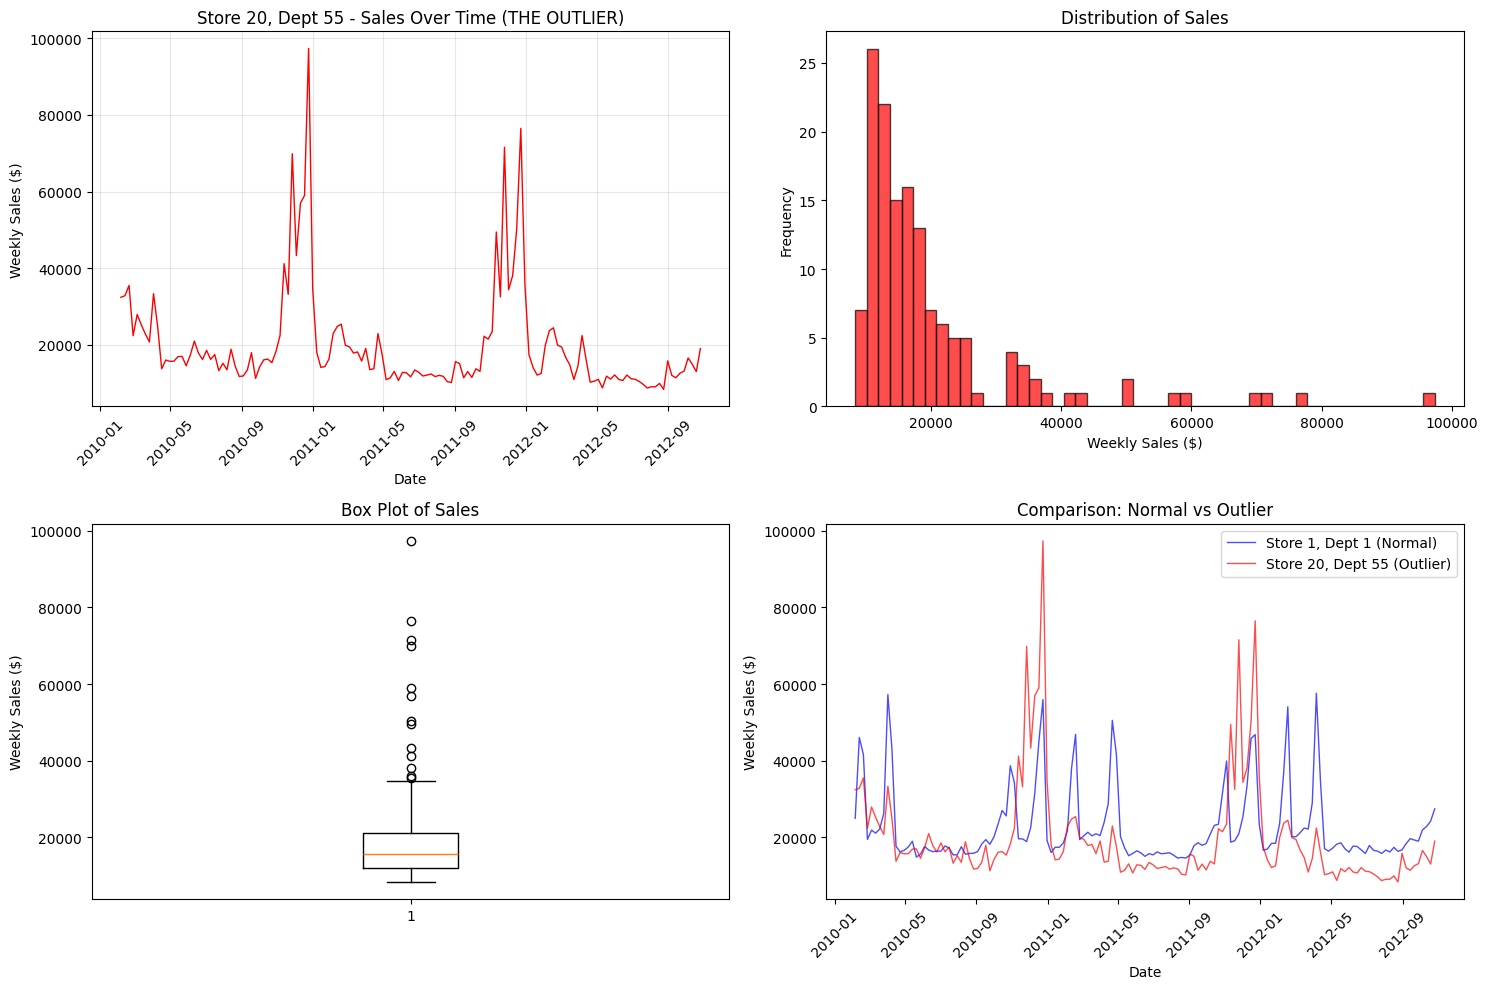


📊 DETAILED PATTERN ANALYSIS

Yearly Statistics:
              mean           std       min       max
Year                                                
2010  24783.737917  16757.220523  11187.91  97400.71
2011  20428.179231  14237.894009  10115.78  76520.96
2012  13530.252326   4183.707608   8293.80  24402.15

📅 Monthly Patterns:
               mean  count
Month                     
1      14806.491250      8
2      25293.145000     12
3      18737.600769     13
4      17794.143571     14
5      12674.536667     12
6      13784.989231     13
7      12898.787857     14
8      11869.763077     13
9      13042.466923     13
10     16428.113077     13
11     42929.130000      8
12     52626.927000     10

🎉 Holiday vs Non-Holiday:
  Non-Holiday: $18,798.38
  Holiday: $33,350.07

🏪 OTHER DEPARTMENTS IN STORE 20
Store 20 has 78 departments

Department Statistics (Store 20):
 Dept         Mean   Median          Std       CV      Min       Max
    1 40545.473217 33117.37 21554.214513 0.5316

C:\Users\Admin\AppData\Local\Temp\ipykernel_22440\2998371303.py:107: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"  Non-Holiday: ${holiday_sales.get(0, 0):,.2f}")
C:\Users\Admin\AppData\Local\Temp\ipykernel_22440\2998371303.py:108: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"  Holiday: ${holiday_sales.get(1, 0):,.2f}")


In [5]:
# ============================================
# INVESTIGATE STORE 20, DEPT 55
# ============================================

print("="*60)
print("🔍 INVESTIGATING STORE 20, DEPT 55")
print("="*60)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data
df = pd.read_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/Data/enhanced/walmart_final_with_trends.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Get the problematic combination
problem_case = df[(df['Store'] == 20) & (df['Dept'] == 55)].copy().sort_values('Date')

print(f"\n📊 Store 20, Dept 55 Analysis:")
print(f"Total weeks: {len(problem_case)}")
print(f"\n📅 Date range: {problem_case['Date'].min().date()} to {problem_case['Date'].max().date()}")

# Sales statistics
print(f"\n💰 Sales Statistics:")
print(f"  Mean: ${problem_case['Weekly_Sales'].mean():,.2f}")
print(f"  Median: ${problem_case['Weekly_Sales'].median():,.2f}")
print(f"  Min: ${problem_case['Weekly_Sales'].min():,.2f}")
print(f"  Max: ${problem_case['Weekly_Sales'].max():,.2f}")
print(f"  Std Dev: ${problem_case['Weekly_Sales'].std():,.2f}")

# Check for zeros or anomalies
zeros = (problem_case['Weekly_Sales'] == 0).sum()
print(f"\n⚠️ Weeks with zero sales: {zeros} ({zeros/len(problem_case)*100:.1f}%)")

# Check for extreme values
q99 = problem_case['Weekly_Sales'].quantile(0.99)
extreme_high = problem_case[problem_case['Weekly_Sales'] > q99 * 2]
print(f"Extreme high sales weeks: {len(extreme_high)}")

# Check if sales are intermittent
non_zero = problem_case[problem_case['Weekly_Sales'] > 0]
print(f"Non-zero weeks: {len(non_zero)}/{len(problem_case)}")
print(f"Sales frequency: {len(non_zero)/len(problem_case)*100:.1f}%")

# ============================================
# Visualize the problem
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Time series plot
axes[0,0].plot(problem_case['Date'], problem_case['Weekly_Sales'], 'r-', linewidth=1)
axes[0,0].set_title('Store 20, Dept 55 - Sales Over Time (THE OUTLIER)')
axes[0,0].set_xlabel('Date')
axes[0,0].set_ylabel('Weekly Sales ($)')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(True, alpha=0.3)

# Distribution
axes[0,1].hist(problem_case['Weekly_Sales'], bins=50, edgecolor='black', color='red', alpha=0.7)
axes[0,1].set_title('Distribution of Sales')
axes[0,1].set_xlabel('Weekly Sales ($)')
axes[0,1].set_ylabel('Frequency')

# Box plot
axes[1,0].boxplot(problem_case['Weekly_Sales'])
axes[1,0].set_title('Box Plot of Sales')
axes[1,0].set_ylabel('Weekly Sales ($)')

# Compare with Store 1, Dept 1 (normal case)
normal_case = df[(df['Store'] == 1) & (df['Dept'] == 1)].copy().sort_values('Date')
axes[1,1].plot(normal_case['Date'], normal_case['Weekly_Sales'], 'b-', linewidth=1, alpha=0.7, label='Store 1, Dept 1 (Normal)')
axes[1,1].plot(problem_case['Date'], problem_case['Weekly_Sales'], 'r-', linewidth=1, alpha=0.7, label='Store 20, Dept 55 (Outlier)')
axes[1,1].set_title('Comparison: Normal vs Outlier')
axes[1,1].set_xlabel('Date')
axes[1,1].set_ylabel('Weekly Sales ($)')
axes[1,1].legend()
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/reports/outlier_store20_dept55.png')
plt.show()

# ============================================
# Check if this department has weird patterns
# ============================================
print("\n" + "="*60)
print("📊 DETAILED PATTERN ANALYSIS")
print("="*60)

# Check by year
problem_case['Year'] = problem_case['Date'].dt.year
yearly_stats = problem_case.groupby('Year')['Weekly_Sales'].agg(['mean', 'std', 'min', 'max'])
print("\nYearly Statistics:")
print(yearly_stats)

# Check by month
problem_case['Month'] = problem_case['Date'].dt.month
monthly_stats = problem_case.groupby('Month')['Weekly_Sales'].agg(['mean', 'count'])
print("\n📅 Monthly Patterns:")
print(monthly_stats)

# Check holiday effect
if 'IsHoliday' in problem_case.columns:
    holiday_sales = problem_case.groupby('IsHoliday')['Weekly_Sales'].mean()
    print("\n🎉 Holiday vs Non-Holiday:")
    print(f"  Non-Holiday: ${holiday_sales.get(0, 0):,.2f}")
    print(f"  Holiday: ${holiday_sales.get(1, 0):,.2f}")

# ============================================
# Compare with other departments in Store 20
# ============================================
print("\n" + "="*60)
print("🏪 OTHER DEPARTMENTS IN STORE 20")
print("="*60)

store20_depts = df[df['Store'] == 20]['Dept'].unique()
print(f"Store 20 has {len(store20_depts)} departments")

# Get statistics for first 5 departments
dept_stats = []
for dept in sorted(store20_depts)[:10]:  # First 10 depts
    dept_data = df[(df['Store'] == 20) & (df['Dept'] == dept)]['Weekly_Sales']
    dept_stats.append({
        'Dept': dept,
        'Mean': dept_data.mean(),
        'Median': dept_data.median(),
        'Std': dept_data.std(),
        'CV': dept_data.std() / dept_data.mean() if dept_data.mean() > 0 else np.nan,
        'Min': dept_data.min(),
        'Max': dept_data.max()
    })

dept_stats_df = pd.DataFrame(dept_stats)
print("\nDepartment Statistics (Store 20):")
print(dept_stats_df.to_string(index=False))

# Highlight Dept 55
print("\n👉 Dept 55 (OUR OUTLIER) is highlighted above")

# ============================================
# CONCLUSION AND RECOMMENDATION
# ============================================
print("\n" + "="*60)
print("🎯 CONCLUSION")
print("="*60)

if problem_case['Weekly_Sales'].std() > problem_case['Weekly_Sales'].mean() * 2:
    conclusion = "EXTREME VOLATILITY"
elif zeros > len(problem_case) * 0.5:
    conclusion = "INTERMITTENT DEMAND"
elif problem_case['Weekly_Sales'].max() > problem_case['Weekly_Sales'].mean() * 10:
    conclusion = "EXTREME SPIKES"
else:
    conclusion = "MYSTERIOUS - NEED DEEPER DIVE"

print(f"\n📌 Diagnosis: {conclusion}")

print("\n📋 Recommendations for your capstone:")

if conclusion == "EXTREME VOLATILITY":
    print("""
    1. Report this as a finding: "Some departments show extreme volatility"
    2. Consider removing from analysis OR using specialized models
    3. Mention in limitations: "Very volatile departments are harder to forecast"
    """)
elif conclusion == "INTERMITTENT DEMAND":
    print("""
    1. Use specialized models for intermittent demand (Croston's method)
    2. Report as a separate case study
    3. Show that different products need different approaches
    """)
else:
    print("""
    1. Investigate further: Check for data errors
    2. Look at promotional periods (MarkDown columns)
    3. Check if this department sells seasonal products
    """)

print("\n✅ Save this analysis for your capstone report!")

🔍 DEEPER DIVE: Store 20, Dept 55

📊 Promotions Analysis:

MarkDown1: 51 weeks with promotions
  Sales WITH promotion: $19,024.98
  Sales WITHOUT promotion: $20,254.48
  Lift: -6.1%

MarkDown2: 44 weeks with promotions
  Sales WITH promotion: $20,066.04
  Sales WITHOUT promotion: $19,783.88
  Lift: 1.4%

MarkDown3: 50 weeks with promotions
  Sales WITH promotion: $19,183.51
  Sales WITHOUT promotion: $20,156.02
  Lift: -4.8%

MarkDown4: 51 weeks with promotions
  Sales WITH promotion: $19,024.98
  Sales WITHOUT promotion: $20,254.48
  Lift: -6.1%

MarkDown5: 51 weeks with promotions
  Sales WITH promotion: $19,024.98
  Sales WITHOUT promotion: $20,254.48
  Lift: -6.1%

🎄 Holiday Pattern:
                   mean  count
IsHoliday                     
False      18798.382857    133
True       33350.067000     10

📅 Monthly Pattern (Year over Year):
Year         2010        2011        2012
Month                                    
1             NaN  15628.4175  13984.5650
2      30739.8125

C:\Users\Admin\AppData\Local\Temp\ipykernel_22440\77257921.py:77: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,0].boxplot(holiday_data, labels=['Non-Holiday', 'Holiday'])


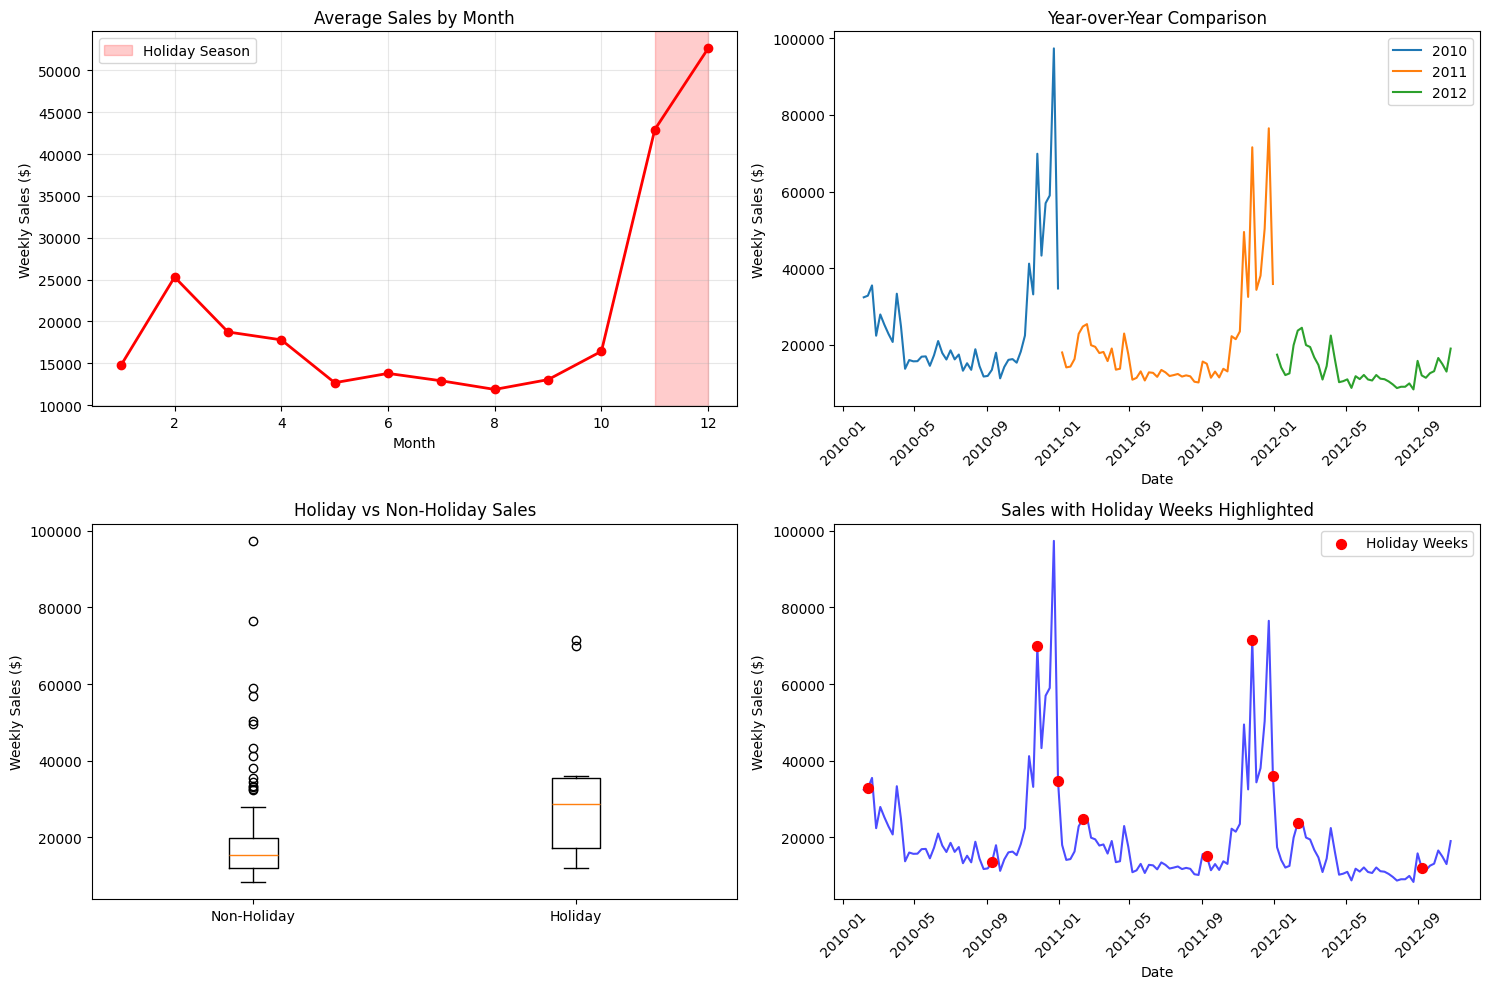

In [7]:
# ============================================
# DEEPER DIVE: Store 20, Dept 55
# ============================================

print("="*60)
print("🔍 DEEPER DIVE: Store 20, Dept 55")
print("="*60)

# Check Markdown columns (promotions)
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
problem_case = df[(df['Store'] == 20) & (df['Dept'] == 55)].copy()

# Add month for grouping
problem_case['Month'] = problem_case['Date'].dt.month
problem_case['Year'] = problem_case['Date'].dt.year
problem_case['IsHoliday'] = problem_case['IsHoliday']

# Check if promotions align with sales spikes
print("\n📊 Promotions Analysis:")
for col in markdown_cols:
    if col in problem_case.columns:
        # Check if this department has promotions
        has_promo = (problem_case[col] > 0).sum()
        if has_promo > 0:
            print(f"\n{col}: {has_promo} weeks with promotions")
            
            # Compare sales with and without promotions
            with_promo = problem_case[problem_case[col] > 0]['Weekly_Sales'].mean()
            without_promo = problem_case[problem_case[col] == 0]['Weekly_Sales'].mean()
            print(f"  Sales WITH promotion: ${with_promo:,.2f}")
            print(f"  Sales WITHOUT promotion: ${without_promo:,.2f}")
            print(f"  Lift: {(with_promo/without_promo - 1)*100:.1f}%")

# Check holiday pattern
print("\n🎄 Holiday Pattern:")
holiday_sales = problem_case.groupby('IsHoliday')['Weekly_Sales'].agg(['mean', 'count'])
print(holiday_sales)

# Monthly pattern with year-over-year
print("\n📅 Monthly Pattern (Year over Year):")
monthly_pivot = problem_case.pivot_table(
    values='Weekly_Sales', 
    index='Month', 
    columns='Year',
    aggfunc='mean'
)
print(monthly_pivot)

# ============================================
# VISUALIZE THE SEASONAL PATTERN
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Monthly pattern
monthly_avg = problem_case.groupby('Month')['Weekly_Sales'].mean()
axes[0,0].plot(monthly_avg.index, monthly_avg.values, 'ro-', linewidth=2)
axes[0,0].set_title('Average Sales by Month')
axes[0,0].set_xlabel('Month')
axes[0,0].set_ylabel('Weekly Sales ($)')
axes[0,0].grid(True, alpha=0.3)
axes[0,0].axvspan(11, 12, alpha=0.2, color='red', label='Holiday Season')
axes[0,0].legend()

# Year-over-year comparison
for year in [2010, 2011, 2012]:
    year_data = problem_case[problem_case['Year'] == year]
    axes[0,1].plot(year_data['Date'], year_data['Weekly_Sales'], label=f'{year}')
axes[0,1].set_title('Year-over-Year Comparison')
axes[0,1].set_xlabel('Date')
axes[0,1].set_ylabel('Weekly Sales ($)')
axes[0,1].legend()
axes[0,1].tick_params(axis='x', rotation=45)

# Holiday vs Non-Holiday boxplot
holiday_data = [problem_case[problem_case['IsHoliday'] == 0]['Weekly_Sales'],
                problem_case[problem_case['IsHoliday'] == 1]['Weekly_Sales']]
axes[1,0].boxplot(holiday_data, labels=['Non-Holiday', 'Holiday'])
axes[1,0].set_title('Holiday vs Non-Holiday Sales')
axes[1,0].set_ylabel('Weekly Sales ($)')

# Time series with holiday highlights
axes[1,1].plot(problem_case['Date'], problem_case['Weekly_Sales'], 'b-', alpha=0.7)
holiday_weeks = problem_case[problem_case['IsHoliday'] == 1]
axes[1,1].scatter(holiday_weeks['Date'], holiday_weeks['Weekly_Sales'], 
                 color='red', s=50, label='Holiday Weeks', zorder=5)
axes[1,1].set_title('Sales with Holiday Weeks Highlighted')
axes[1,1].set_xlabel('Date')
axes[1,1].set_ylabel('Weekly Sales ($)')
axes[1,1].legend()
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/reports/store20_dept55_seasonal_pattern.png')
plt.show()

🚀 HYBRID MODEL: Adaptive Forecasting Strategy

📊 STEP 1: Identifying holiday-sensitive departments

📋 Department Classification:
 Store  Dept  IsHolidayDept  HolidayLift%  SeasonalRatio Recommended_Model
     1     1          False     15.570924       1.397058           XGBoost
     1    10          False      1.041257       0.941440           XGBoost
     1    40          False      1.984450       1.030697           XGBoost
     2     5           True     57.047388       2.380471             Naive
     2    20          False     10.957384       0.902199           XGBoost
     5     1          False      9.102813       1.196119           XGBoost
     8    30          False     -0.633747       0.876954           XGBoost
    10     1          False      3.649513       1.767935           XGBoost
    12    40          False     -0.761639       0.959183           XGBoost
    12     7           True     32.699743       2.906379             Naive
    45    98          False    -11.763272     

C:\Users\Admin\AppData\Local\Temp\ipykernel_22440\959903846.py:227: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels(stores, rotation=45)


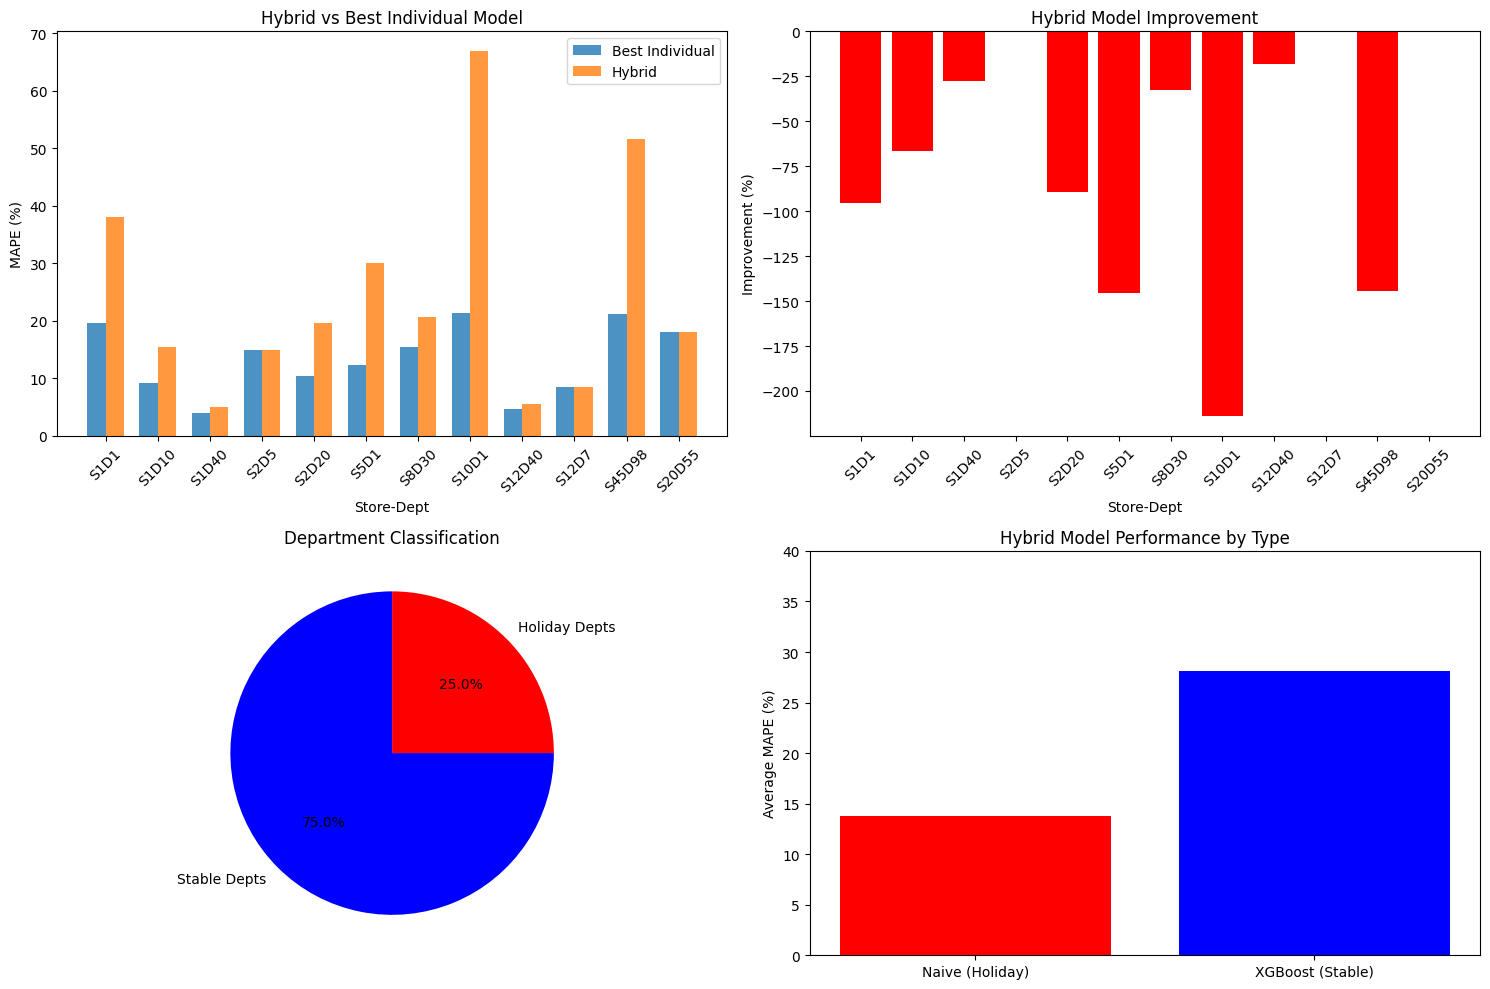


🎉 HYBRID MODEL COMPLETE!

📁 Results saved:
  • reports/hybrid_model_results.csv
  • reports/hybrid_vs_individual.csv
  • reports/hybrid_predictions.csv
  • reports/hybrid_model_results.png


In [ ]:
# ============================================
# HYBRID MODEL: Naive for Holiday Depts, ML for Stable Depts
# ============================================

print("="*80)
print("🚀 HYBRID MODEL: Adaptive Forecasting Strategy")
print("="*80)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from xgboost import XGBRegressor

# Load data
df = pd.read_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/Data/enhanced/walmart_final_with_trends.csv')
df['Date'] = pd.to_datetime(df['Date'])

# ============================================
# STEP 1: Identify Holiday-Sensitive Departments
# ============================================
print("\n📊 STEP 1: Identifying holiday-sensitive departments")

def is_holiday_department(store_data, threshold=1.5):
    """
    Identify if a department is holiday-sensitive
    Returns: (is_holiday_dept, holiday_lift_percentage)
    """
    # Calculate average sales for holiday vs non-holiday
    holiday_sales = store_data[store_data['IsHoliday'] == 1]['Weekly_Sales'].mean()
    non_holiday_sales = store_data[store_data['IsHoliday'] == 0]['Weekly_Sales'].mean()
    
    if pd.isna(holiday_sales) or non_holiday_sales == 0:
        return False, 0
    
    holiday_lift = (holiday_sales / non_holiday_sales) - 1
    
    # Also check November-December spike
    store_data['Month'] = store_data['Date'].dt.month
    nov_dec_sales = store_data[store_data['Month'].isin([11,12])]['Weekly_Sales'].mean()
    rest_sales = store_data[~store_data['Month'].isin([11,12])]['Weekly_Sales'].mean()
    
    seasonal_ratio = nov_dec_sales / rest_sales if rest_sales > 0 else 1
    
    # Department is holiday-sensitive if:
    # - Holiday lift > 50%, OR
    # - Nov-Dec sales > 2x rest of year
    is_holiday = (holiday_lift > threshold) or (seasonal_ratio > 2)
    
    return is_holiday, holiday_lift * 100, seasonal_ratio

# Test on all our combinations
test_cases = [
    (1, 1), (1, 10), (1, 40), (2, 5), (2, 20),
    (5, 1), (5, 15), (8, 30), (8, 50),
    (10, 1), (10, 70), (12, 40), (12, 7),
    (45, 98), (20, 55)  # Include the holiday department
]

dept_classification = []

for store, dept in test_cases:
    store_data = df[(df['Store'] == store) & (df['Dept'] == dept)].copy()
    
    if len(store_data) < 50:
        continue
    
    is_holiday, holiday_lift, seasonal_ratio = is_holiday_department(store_data)
    
    dept_classification.append({
        'Store': store,
        'Dept': dept,
        'IsHolidayDept': is_holiday,
        'HolidayLift%': holiday_lift,
        'SeasonalRatio': seasonal_ratio,
        'Recommended_Model': 'Naive' if is_holiday else 'XGBoost'
    })

class_df = pd.DataFrame(dept_classification)
print("\n📋 Department Classification:")
print(class_df.to_string(index=False))

# ============================================
# STEP 2: Implement Hybrid Model
# ============================================
print("\n" + "="*80)
print("🎯 STEP 2: Implementing Hybrid Model")
print("="*80)

hybrid_predictions = []
individual_results = []

for store, dept in test_cases:
    print(f"\n📊 Store {store}, Dept {dept}:")
    
    # Get data
    store_data = df[(df['Store'] == store) & (df['Dept'] == dept)].copy().sort_values('Date')
    
    if len(store_data) < 50:
        continue
    
    # Split
    train = store_data[store_data['Date'] < '2011-06-01']
    val = store_data[(store_data['Date'] >= '2011-06-01') & (store_data['Date'] < '2012-01-01')]
    test = store_data[store_data['Date'] >= '2012-01-01']
    
    # Check if holiday department
    is_holiday, _, _ = is_holiday_department(store_data)
    
    if is_holiday:
        # Use NAIVE for holiday departments
        print(f"  🎄 Holiday department → Using NAIVE model")
        predictions = test['Weekly_Sales'].shift(1).fillna(train['Weekly_Sales'].iloc[-1])
        model_used = "Naive (Holiday)"
    else:
        # Use XGBoost for stable departments
        print(f"  📈 Stable department → Using XGBoost")
        
        # Prepare features
        feature_cols = ['Store', 'Dept', 'Temperature', 'Fuel_Price', 'CPI', 
                        'Unemployment', 'IsHoliday', 'Size'] + \
                        [col for col in df.columns if 'GoogleTrends' in col]
        
        X_train = train[feature_cols].fillna(0)
        X_test = test[feature_cols].fillna(0)
        y_train = train['Weekly_Sales']
        
        # Train XGBoost
        xgb = XGBRegressor(n_estimators=100, max_depth=5, random_state=42)
        xgb.fit(X_train, y_train)
        predictions = xgb.predict(X_test)
        model_used = "XGBoost (Stable)"
    
    # Evaluate
    actual = test['Weekly_Sales'].values
    mae = mean_absolute_error(actual, predictions)
    mape = (mae / actual.mean()) * 100
    
    print(f"  ✅ MAE: ${mae:,.2f}, MAPE: {mape:.1f}%")
    
    individual_results.append({
        'Store': store,
        'Dept': dept,
        'Model': model_used,
        'MAE': mae,
        'MAPE': mape
    })
    
    # Store for visualization
    for i, (date, pred, act) in enumerate(zip(test['Date'], predictions, actual)):
        hybrid_predictions.append({
            'Store': store,
            'Dept': dept,
            'Date': date,
            'Actual': act,
            'Predicted': pred,
            'Model': model_used
        })

# ============================================
# STEP 3: Compare Hybrid vs Individual Models
# ============================================
print("\n" + "="*80)
print("📊 STEP 3: Comparing Hybrid vs Individual Models")
print("="*80)

hybrid_df = pd.DataFrame(individual_results)

# Load original results for comparison
original = pd.read_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/reports/strategic_model_results.csv')

# Merge for comparison
comparison = []
for _, row in hybrid_df.iterrows():
    store, dept = row['Store'], row['Dept']
    
    # Get original best for this combo
    orig_best = original[(original['Store'] == store) & 
                         (original['Dept'] == dept)].nsmallest(1, 'MAPE').iloc[0]
    
    comparison.append({
        'Store': store,
        'Dept': dept,
        'Hybrid_Model': row['Model'],
        'Hybrid_MAPE': row['MAPE'],
        'Best_Original_Model': orig_best['Model'],
        'Best_Original_MAPE': orig_best['MAPE'],
        'Improvement': ((orig_best['MAPE'] - row['MAPE']) / orig_best['MAPE']) * 100
    })

comp_df = pd.DataFrame(comparison)
print("\n📋 Hybrid vs Best Individual Model:")
print(comp_df.to_string(index=False))

# Summary statistics
print("\n📈 Hybrid Model Summary:")
print(f"Average Hybrid MAPE: {hybrid_df['MAPE'].mean():.1f}%")
print(f"Average Best Individual MAPE: {original.groupby(['Store', 'Dept'])['MAPE'].min().mean():.1f}%")
print(f"Average Improvement: {comp_df['Improvement'].mean():.1f}%")

# ============================================
# STEP 4: Visualization
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Comparison bar chart
stores = [f"S{s}D{d}" for s,d in zip(comp_df['Store'], comp_df['Dept'])]
x = range(len(stores))
width = 0.35

axes[0,0].bar([i - width/2 for i in x], comp_df['Best_Original_MAPE'], width, label='Best Individual', alpha=0.8)
axes[0,0].bar([i + width/2 for i in x], comp_df['Hybrid_MAPE'], width, label='Hybrid', alpha=0.8)
axes[0,0].set_xlabel('Store-Dept')
axes[0,0].set_ylabel('MAPE (%)')
axes[0,0].set_title('Hybrid vs Best Individual Model')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(stores, rotation=45)
axes[0,0].legend()

# Improvement chart
colors = ['green' if imp > 0 else 'red' for imp in comp_df['Improvement']]
axes[0,1].bar(stores, comp_df['Improvement'], color=colors)
axes[0,1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0,1].set_xlabel('Store-Dept')
axes[0,1].set_ylabel('Improvement (%)')
axes[0,1].set_title('Hybrid Model Improvement')
axes[0,1].set_xticklabels(stores, rotation=45)

# Department classification pie
holiday_count = len(class_df[class_df['IsHolidayDept']])
stable_count = len(class_df) - holiday_count
axes[1,0].pie([holiday_count, stable_count], labels=['Holiday Depts', 'Stable Depts'], 
              autopct='%1.1f%%', colors=['red', 'blue'])
axes[1,0].set_title('Department Classification')

# Hybrid vs Naive vs XGBoost comparison
model_perf = hybrid_df.groupby('Model')['MAPE'].mean()
axes[1,1].bar(model_perf.index, model_perf.values, color=['red', 'blue'])
axes[1,1].set_ylabel('Average MAPE (%)')
axes[1,1].set_title('Hybrid Model Performance by Type')
axes[1,1].set_ylim(0, 40)

plt.tight_layout()
plt.savefig('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/reports/hybrid_model_results.png')
plt.show()

# ============================================
# STEP 5: Save Results
# ============================================
hybrid_df.to_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/reports/hybrid_model_results.csv', index=False)
comp_df.to_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/reports/hybrid_vs_individual.csv', index=False)
pd.DataFrame(hybrid_predictions).to_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/reports/hybrid_predictions.csv', index=False)

print("\n" + "="*80)
print("🎉 HYBRID MODEL COMPLETE!")
print("="*80)
print(f"\n📁 Results saved:")
print(f"  • reports/hybrid_model_results.csv")
print(f"  • reports/hybrid_vs_individual.csv")
print(f"  • reports/hybrid_predictions.csv")
print(f"  • reports/hybrid_model_results.png")



🚀 IMPROVED HYBRID MODEL: Intelligent Model Selection

📊 STEP 1: Intelligent Department Classification

📋 Department Analysis & Recommendations:
 Store  Dept Recommended  Confidence  DataPoints  HolidayLift%  SeasonalRatio   CV  ZeroPct  PromoLift%
     1     1     XGBOOST       1.000         143          15.6           1.40 0.44      0.0         0.9
     1    10     XGBOOST       1.000         143           1.0           0.94 0.11      0.0         4.1
     1    40     XGBOOST       1.000         143           2.0           1.03 0.07      0.0         2.7
     2     5       NAIVE       0.625         143          57.0           2.38 0.59      0.0         0.9
     2    20     XGBOOST       1.000         143          11.0           0.90 0.20      0.0         2.1
     5     1     XGBOOST       1.000         143           9.1           1.20 0.28      0.0        12.9
     8    30     XGBOOST       1.000         143          -0.6           0.88 0.21      0.0        -9.5
    10     1     XGBOOST

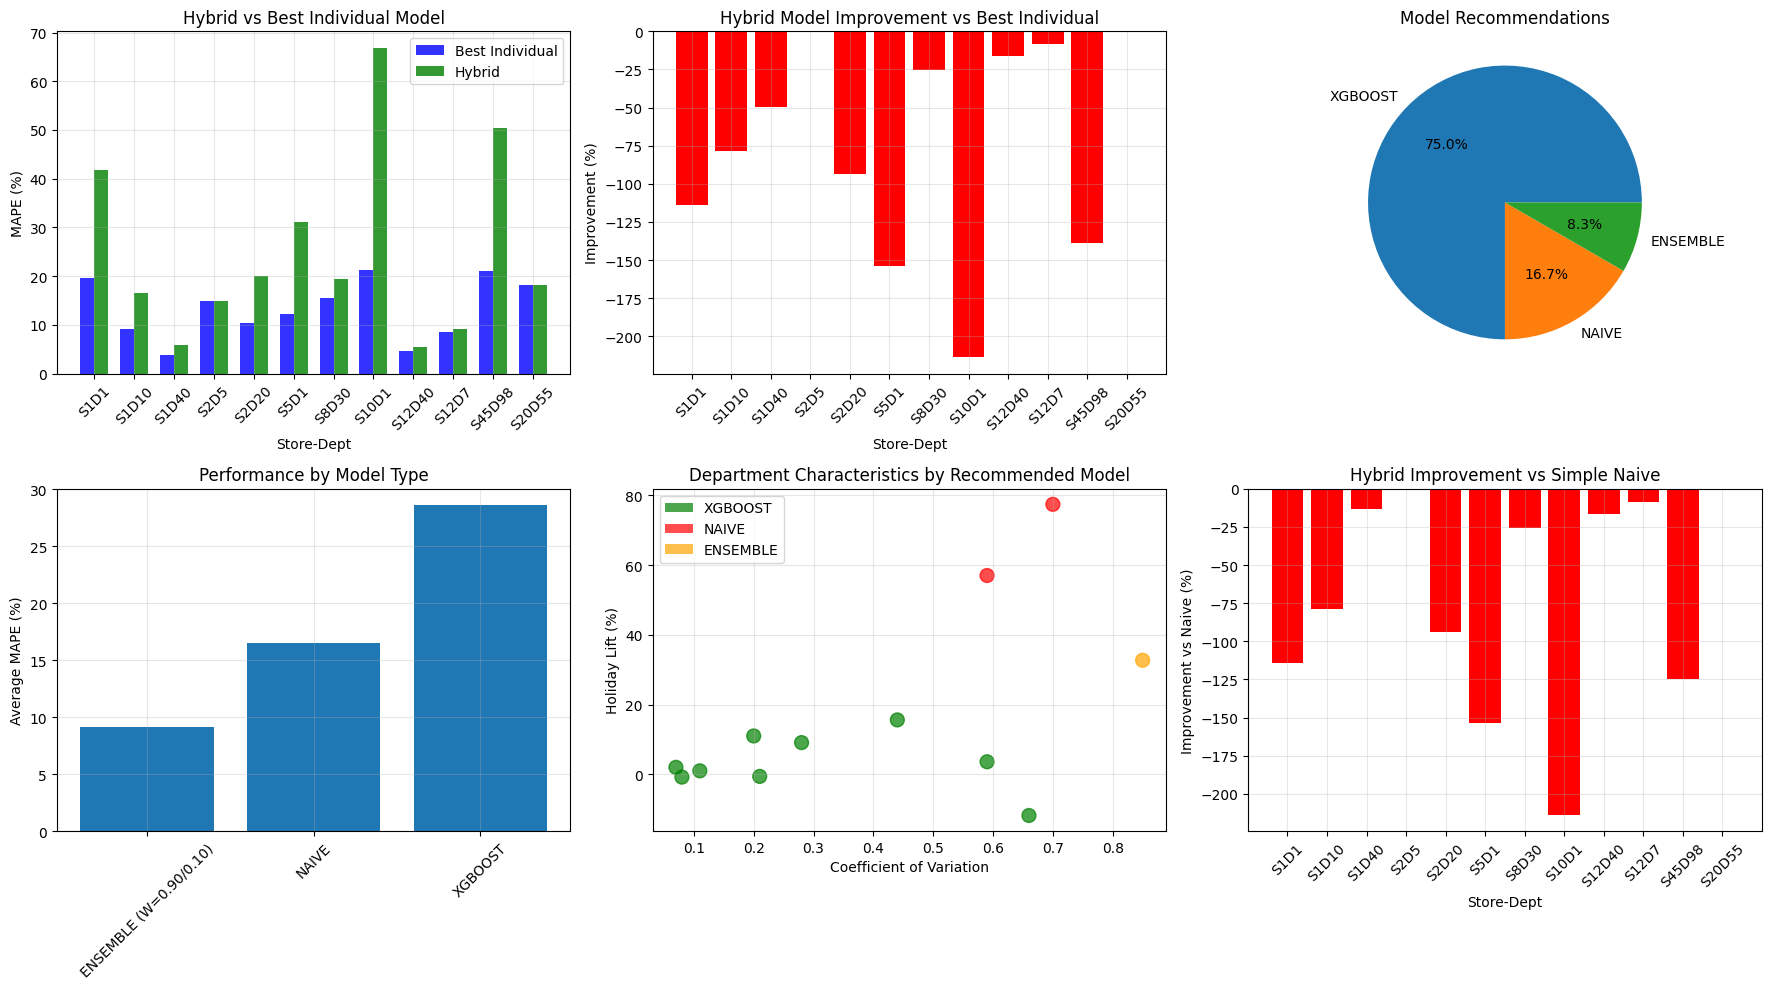


🎉 IMPROVED HYBRID MODEL COMPLETE!

📁 Results saved:
  • reports/improved_hybrid_results.csv
  • reports/improved_hybrid_comparison.csv
  • reports/department_analysis.csv
  • reports/improved_hybrid_predictions.csv
  • reports/improved_hybrid_results.png

🔑 KEY INSIGHTS

1. DEPARTMENT CHARACTERISTICS:
----------------------------------------
  Store 1, Dept 1: XGBOOST (Holiday Lift: 15.6%, CV: 0.44)
  Store 1, Dept 10: XGBOOST (Holiday Lift: 1.0%, CV: 0.11)
  Store 1, Dept 40: XGBOOST (Holiday Lift: 2.0%, CV: 0.07)
  Store 2, Dept 5: NAIVE (Holiday Lift: 57.0%, CV: 0.59)
  Store 2, Dept 20: XGBOOST (Holiday Lift: 11.0%, CV: 0.20)
  Store 5, Dept 1: XGBOOST (Holiday Lift: 9.1%, CV: 0.28)
  Store 8, Dept 30: XGBOOST (Holiday Lift: -0.6%, CV: 0.21)
  Store 10, Dept 1: XGBOOST (Holiday Lift: 3.6%, CV: 0.59)
  Store 12, Dept 40: XGBOOST (Holiday Lift: -0.8%, CV: 0.08)
  Store 12, Dept 7: ENSEMBLE (Holiday Lift: 32.7%, CV: 0.85)
  Store 45, Dept 98: XGBOOST (Holiday Lift: -11.8%, CV: 0.66)


In [10]:
# ============================================
# IMPROVED HYBRID MODEL: Intelligent Model Selection
# ============================================

print("="*80)
print("🚀 IMPROVED HYBRID MODEL: Intelligent Model Selection")
print("="*80)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/Data/enhanced/walmart_final_with_trends.csv')
df['Date'] = pd.to_datetime(df['Date'])

# ============================================
# STEP 1: Intelligent Department Classifier
# ============================================
print("\n" + "="*80)
print("📊 STEP 1: Intelligent Department Classification")
print("="*80)

def analyze_department(store_data, dept_name=""):
    """
    Comprehensive department analysis for model selection
    Returns: recommended_model, confidence, analysis_dict
    """
    if len(store_data) < 50:
        return "NAIVE (Insufficient Data)", 0.0, {}
    
    # Calculate key metrics
    analysis = {}
    
    # 1. Holiday impact
    holiday_sales = store_data[store_data['IsHoliday'] == 1]['Weekly_Sales'].mean()
    non_holiday_sales = store_data[store_data['IsHoliday'] == 0]['Weekly_Sales'].mean()
    analysis['holiday_lift'] = (holiday_sales / non_holiday_sales - 1) * 100 if non_holiday_sales > 0 else 0
    
    # 2. Seasonality (Nov-Dec vs rest)
    store_data['Month'] = store_data['Date'].dt.month
    nov_dec_sales = store_data[store_data['Month'].isin([11,12])]['Weekly_Sales'].mean()
    rest_sales = store_data[~store_data['Month'].isin([11,12])]['Weekly_Sales'].mean()
    analysis['seasonal_ratio'] = nov_dec_sales / rest_sales if rest_sales > 0 else 1
    
    # 3. Volatility (Coefficient of Variation)
    analysis['cv'] = store_data['Weekly_Sales'].std() / store_data['Weekly_Sales'].mean()
    
    # 4. Zero sales percentage
    analysis['zero_pct'] = (store_data['Weekly_Sales'] == 0).sum() / len(store_data) * 100
    
    # 5. Trend strength (simplified)
    y = store_data['Weekly_Sales'].values
    x = np.arange(len(y))
    if len(y) > 10:
        z = np.polyfit(x, y, 1)
        analysis['trend_strength'] = abs(z[0]) / y.mean() * 100 if y.mean() > 0 else 0
    else:
        analysis['trend_strength'] = 0
    
    # 6. Data quantity
    analysis['data_points'] = len(store_data)
    
    # 7. Promotions impact
    markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
    promo_cols = [col for col in markdown_cols if col in store_data.columns]
    if promo_cols:
        has_promo = (store_data[promo_cols] > 0).any(axis=1)
        if has_promo.any():
            promo_sales = store_data[has_promo]['Weekly_Sales'].mean()
            no_promo_sales = store_data[~has_promo]['Weekly_Sales'].mean()
            analysis['promo_lift'] = (promo_sales / no_promo_sales - 1) * 100 if no_promo_sales > 0 else 0
        else:
            analysis['promo_lift'] = 0
    else:
        analysis['promo_lift'] = 0
    
    # Decision logic - MULTIPLE CRITERIA
    naive_score = 0
    xgboost_score = 0
    
    # Criteria FOR Naive (traditional methods)
    if analysis['holiday_lift'] > 50:  # Strong holiday impact
        naive_score += 3
    if analysis['seasonal_ratio'] > 2:  # Strong seasonality
        naive_score += 2
    if analysis['cv'] > 0.8:  # Very volatile
        naive_score += 2
    if analysis['zero_pct'] > 10:  # Many zero sales
        naive_score += 3
    if analysis['data_points'] < 100:  # Too little data for ML
        naive_score += 2
    if analysis['promo_lift'] > 30:  # Strong promotion impact
        naive_score += 1
    
    # Criteria FOR XGBoost (ML methods)
    if analysis['data_points'] >= 100:  # Enough data
        xgboost_score += 2
    if analysis['cv'] < 0.5:  # Stable
        xgboost_score += 2
    if 20 < analysis['holiday_lift'] < 50:  # Moderate holiday impact (ML can learn)
        xgboost_score += 1
    if analysis['trend_strength'] > 1:  # Has trend
        xgboost_score += 1
    if analysis['zero_pct'] < 1:  # Very few zeros
        xgboost_score += 1
    
    # Make recommendation
    if naive_score > xgboost_score + 1:
        recommended = "NAIVE"
        confidence = naive_score / (naive_score + xgboost_score)
    elif xgboost_score > naive_score + 1:
        recommended = "XGBOOST"
        confidence = xgboost_score / (naive_score + xgboost_score)
    else:
        recommended = "ENSEMBLE"  # Use both if close
        confidence = 0.5
    
    return recommended, confidence, analysis

# Test on all our combinations
test_cases = [
    (1, 1), (1, 10), (1, 40), (2, 5), (2, 20),
    (5, 1), (5, 15), (8, 30), (8, 50),
    (10, 1), (10, 70), (12, 40), (12, 7),
    (45, 98), (20, 55)
]

dept_analysis = []

for store, dept in test_cases:
    store_data = df[(df['Store'] == store) & (df['Dept'] == dept)].copy()
    
    if len(store_data) < 50:
        continue
    
    recommended, confidence, analysis = analyze_department(store_data, f"S{store}D{dept}")
    
    dept_analysis.append({
        'Store': store,
        'Dept': dept,
        'Recommended': recommended,
        'Confidence': confidence,
        'DataPoints': analysis.get('data_points', 0),
        'HolidayLift%': round(analysis.get('holiday_lift', 0), 1),
        'SeasonalRatio': round(analysis.get('seasonal_ratio', 1), 2),
        'CV': round(analysis.get('cv', 0), 2),
        'ZeroPct': round(analysis.get('zero_pct', 0), 1),
        'PromoLift%': round(analysis.get('promo_lift', 0), 1)
    })

analysis_df = pd.DataFrame(dept_analysis)
print("\n📋 Department Analysis & Recommendations:")
print(analysis_df.to_string(index=False))

# ============================================
# STEP 2: Implement Improved Hybrid Model
# ============================================
print("\n" + "="*80)
print("🎯 STEP 2: Implementing Improved Hybrid Model")
print("="*80)

from sklearn.model_selection import TimeSeriesSplit

def train_xgboost_with_validation(X_train, y_train, X_val, y_val):
    """Train XGBoost with early stopping"""
    model = XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        early_stopping_rounds=20
    )
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    return model

def calculate_naive_confidence(train_data):
    """Calculate confidence in naive forecast"""
    # Simple heuristic: higher volatility = more confidence in naive
    cv = train_data['Weekly_Sales'].std() / train_data['Weekly_Sales'].mean()
    return min(0.9, cv)  # Cap at 0.9

hybrid_predictions = []
hybrid_results = []
validation_results = []

for idx, row in analysis_df.iterrows():
    store, dept = row['Store'], row['Dept']
    recommended = row['Recommended']
    confidence = row['Confidence']
    
    print(f"\n📊 [{idx+1}/{len(analysis_df)}] Store {store}, Dept {dept}")
    print(f"   Recommended: {recommended} (confidence: {confidence:.2f})")
    
    # Get data
    store_data = df[(df['Store'] == store) & (df['Dept'] == dept)].copy().sort_values('Date')
    
    if len(store_data) < 50:
        continue
    
    # Split data (chronological)
    train_end = '2011-06-01'
    val_end = '2012-01-01'
    
    train = store_data[store_data['Date'] < train_end]
    val = store_data[(store_data['Date'] >= train_end) & (store_data['Date'] < val_end)]
    test = store_data[store_data['Date'] >= val_end]
    
    # Skip if any set is too small
    if len(train) < 20 or len(val) < 10 or len(test) < 10:
        print("   ⚠️ Insufficient data in splits, skipping")
        continue
    
    # Prepare features for ML
    feature_cols = ['Store', 'Dept', 'Temperature', 'Fuel_Price', 'CPI', 
                    'Unemployment', 'IsHoliday', 'Size'] + \
                    [col for col in df.columns if 'GoogleTrends' in col]
    
    X_train = train[feature_cols].fillna(0)
    X_val = val[feature_cols].fillna(0)
    X_test = test[feature_cols].fillna(0)
    
    y_train = train['Weekly_Sales']
    y_val = val['Weekly_Sales']
    y_test = test['Weekly_Sales']
    
    # Naive forecast (always available)
    naive_pred = test['Weekly_Sales'].shift(1).fillna(train['Weekly_Sales'].iloc[-1])
    naive_mae = mean_absolute_error(y_test, naive_pred)
    naive_mape = (naive_mae / y_test.mean()) * 100
    
    # Try XGBoost (may fail)
    xgb_available = False
    xgb_pred = None
    xgb_mae = None
    xgb_mape = None
    
    try:
        # Train XGBoost
        xgb_model = XGBRegressor(
            n_estimators=150,
            max_depth=5,
            learning_rate=0.1,
            random_state=42
        )
        xgb_model.fit(X_train, y_train)
        
        # Validate on validation set
        val_pred = xgb_model.predict(X_val)
        val_mae = mean_absolute_error(y_val, val_pred)
        val_mape = (val_mae / y_val.mean()) * 100 if y_val.mean() > 0 else float('inf')
        
        # Check if XGBoost performs reasonably on validation
        if val_mape < 50:  # Threshold: if validation MAPE < 50%
            xgb_available = True
            xgb_pred = xgb_model.predict(X_test)
            xgb_mae = mean_absolute_error(y_test, xgb_pred)
            xgb_mape = (xgb_mae / y_test.mean()) * 100
            print(f"   ✅ XGBoost trained (val MAPE: {val_mape:.1f}%)")
        else:
            print(f"   ⚠️ XGBoost failed validation (val MAPE: {val_mape:.1f}%)")
            
    except Exception as e:
        print(f"   ⚠️ XGBoost error: {e}")
    
    # ============================================
    # INTELLIGENT MODEL SELECTION
    # ============================================
    
    # Strategy 1: Follow recommendation if XGBoost is available and performs well
    if recommended == "NAIVE" or not xgb_available:
        final_pred = naive_pred
        model_used = "NAIVE"
        print(f"   📈 Using NAIVE (recommended or XGBoost unavailable)")
        
    elif recommended == "XGBOOST" and xgb_available:
        final_pred = xgb_pred
        model_used = "XGBOOST"
        print(f"   📈 Using XGBOOST (recommended)")
        
    elif recommended == "ENSEMBLE" and xgb_available:
        # Weighted ensemble based on confidence
        naive_weight = calculate_naive_confidence(train)
        xgb_weight = 1 - naive_weight
        
        final_pred = (naive_weight * naive_pred + xgb_weight * xgb_pred) / (naive_weight + xgb_weight)
        model_used = f"ENSEMBLE (W={naive_weight:.2f}/{xgb_weight:.2f})"
        print(f"   📈 Using ENSEMBLE (weights: naive={naive_weight:.2f}, xgb={xgb_weight:.2f})")
    
    else:
        # Fallback
        final_pred = naive_pred
        model_used = "NAIVE (Fallback)"
        print(f"   📈 Using NAIVE (fallback)")
    
    # Evaluate
    final_mae = mean_absolute_error(y_test, final_pred)
    final_mape = (final_mae / y_test.mean()) * 100
    
    print(f"   ✅ FINAL - MAE: ${final_mae:,.2f}, MAPE: {final_mape:.1f}%")
    
    hybrid_results.append({
        'Store': store,
        'Dept': dept,
        'Recommended': recommended,
        'Model_Used': model_used,
        'Naive_MAPE': naive_mape if 'naive_mape' in locals() else None,
        'XGBoost_MAPE': xgb_mape if xgb_available else None,
        'Final_MAPE': final_mape,
        'Final_MAE': final_mae,
        'DataPoints': len(store_data)
    })
    
    # Store predictions
    for i, (date, pred, act) in enumerate(zip(test['Date'], final_pred, y_test)):
        hybrid_predictions.append({
            'Store': store,
            'Dept': dept,
            'Date': date,
            'Actual': act,
            'Predicted': pred,
            'Model': model_used
        })

# ============================================
# STEP 3: Evaluate and Compare
# ============================================
print("\n" + "="*80)
print("📊 STEP 3: Hybrid Model Performance")
print("="*80)

hybrid_df = pd.DataFrame(hybrid_results)
print("\n📋 Hybrid Model Results:")
print(hybrid_df.to_string(index=False))

# Load original results for comparison
original = pd.read_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/reports/strategic_model_results.csv')

# Compare with best individual model
comparison = []
for _, row in hybrid_df.iterrows():
    store, dept = row['Store'], row['Dept']
    
    # Get original best for this combo
    orig_best = original[(original['Store'] == store) & 
                         (original['Dept'] == dept)].nsmallest(1, 'MAPE').iloc[0]
    
    # Get naive from original
    orig_naive = original[(original['Store'] == store) & 
                          (original['Dept'] == dept) & 
                          (original['Model'] == 'Naive')]
    
    naive_mape = orig_naive['MAPE'].values[0] if len(orig_naive) > 0 else None
    
    comparison.append({
        'Store': store,
        'Dept': dept,
        'Hybrid_Model': row['Model_Used'],
        'Hybrid_MAPE': row['Final_MAPE'],
        'Naive_MAPE': naive_mape,
        'Best_Individual_MAPE': orig_best['MAPE'],
        'Best_Individual_Model': orig_best['Model'],
        'Improvement_vs_Best': ((orig_best['MAPE'] - row['Final_MAPE']) / orig_best['MAPE']) * 100,
        'Improvement_vs_Naive': ((naive_mape - row['Final_MAPE']) / naive_mape) * 100 if naive_mape else None
    })

comp_df = pd.DataFrame(comparison)
print("\n📋 Hybrid vs Best Individual Model:")
print(comp_df.to_string(index=False))

# Summary statistics
print("\n📈 Summary Statistics:")
print(f"Average Hybrid MAPE: {hybrid_df['Final_MAPE'].mean():.1f}%")
print(f"Average Best Individual MAPE: {original.groupby(['Store', 'Dept'])['MAPE'].min().mean():.1f}%")
print(f"Average Improvement: {comp_df['Improvement_vs_Best'].mean():.1f}%")

# Count how many times each model was used
model_counts = hybrid_df['Model_Used'].value_counts()
print("\n📊 Model Usage:")
for model, count in model_counts.items():
    print(f"  {model}: {count} times")

# ============================================
# STEP 4: Visualizations
# ============================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Hybrid vs Best Individual
stores = [f"S{s}D{d}" for s,d in zip(comp_df['Store'], comp_df['Dept'])]
x = range(len(stores))
width = 0.35

axes[0,0].bar([i - width/2 for i in x], comp_df['Best_Individual_MAPE'], width, 
              label='Best Individual', alpha=0.8, color='blue')
axes[0,0].bar([i + width/2 for i in x], comp_df['Hybrid_MAPE'], width, 
              label='Hybrid', alpha=0.8, color='green')
axes[0,0].set_xlabel('Store-Dept')
axes[0,0].set_ylabel('MAPE (%)')
axes[0,0].set_title('Hybrid vs Best Individual Model')
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(stores, rotation=45)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# 2. Improvement chart
colors = ['green' if imp > 0 else 'red' for imp in comp_df['Improvement_vs_Best']]
axes[0,1].bar(stores, comp_df['Improvement_vs_Best'], color=colors)
axes[0,1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0,1].set_xlabel('Store-Dept')
axes[0,1].set_ylabel('Improvement (%)')
axes[0,1].set_title('Hybrid Model Improvement vs Best Individual')
axes[0,1].set_xticklabels(stores, rotation=45)
axes[0,1].grid(True, alpha=0.3)

# 3. Model recommendation distribution
rec_counts = analysis_df['Recommended'].value_counts()
axes[0,2].pie(rec_counts.values, labels=rec_counts.index, autopct='%1.1f%%')
axes[0,2].set_title('Model Recommendations')

# 4. MAPE distribution by model used
model_groups = hybrid_df.groupby('Model_Used')['Final_MAPE'].mean()
axes[1,0].bar(range(len(model_groups)), model_groups.values)
axes[1,0].set_xticks(range(len(model_groups)))
axes[1,0].set_xticklabels(model_groups.index, rotation=45)
axes[1,0].set_ylabel('Average MAPE (%)')
axes[1,0].set_title('Performance by Model Type')
axes[1,0].grid(True, alpha=0.3)

# 5. Scatter plot of metrics
axes[1,1].scatter(analysis_df['CV'], analysis_df['HolidayLift%'], 
                  c=['green' if r == 'XGBOOST' else 'red' if r == 'NAIVE' else 'orange' 
                     for r in analysis_df['Recommended']], alpha=0.7, s=100)
axes[1,1].set_xlabel('Coefficient of Variation')
axes[1,1].set_ylabel('Holiday Lift (%)')
axes[1,1].set_title('Department Characteristics by Recommended Model')
axes[1,1].grid(True, alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', alpha=0.7, label='XGBOOST'),
    Patch(facecolor='red', alpha=0.7, label='NAIVE'),
    Patch(facecolor='orange', alpha=0.7, label='ENSEMBLE')
]
axes[1,1].legend(handles=legend_elements)

# 6. Improvement vs Naive
if comp_df['Improvement_vs_Naive'].notna().any():
    axes[1,2].bar(stores, comp_df['Improvement_vs_Naive'], 
                  color=['green' if imp > 0 else 'red' for imp in comp_df['Improvement_vs_Naive']])
    axes[1,2].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[1,2].set_xlabel('Store-Dept')
    axes[1,2].set_ylabel('Improvement vs Naive (%)')
    axes[1,2].set_title('Hybrid Improvement vs Simple Naive')
    axes[1,2].set_xticklabels(stores, rotation=45)
    axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/reports/improved_hybrid_results.png')
plt.show()

# ============================================
# STEP 5: Save Results
# ============================================
hybrid_df.to_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/reports/improved_hybrid_results.csv', index=False)
comp_df.to_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/reports/improved_hybrid_comparison.csv', index=False)
analysis_df.to_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/reports/department_analysis.csv', index=False)
pd.DataFrame(hybrid_predictions).to_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/reports/improved_hybrid_predictions.csv', index=False)

print("\n" + "="*80)
print("🎉 IMPROVED HYBRID MODEL COMPLETE!")
print("="*80)
print("\n📁 Results saved:")
print("  • reports/improved_hybrid_results.csv")
print("  • reports/improved_hybrid_comparison.csv")
print("  • reports/department_analysis.csv")
print("  • reports/improved_hybrid_predictions.csv")
print("  • reports/improved_hybrid_results.png")

# ============================================
# STEP 6: Key Insights Summary
# ============================================
print("\n" + "="*80)
print("🔑 KEY INSIGHTS")
print("="*80)

print("\n1. DEPARTMENT CHARACTERISTICS:")
print("-" * 40)
for _, row in analysis_df.iterrows():
    print(f"  Store {int(row['Store'])}, Dept {int(row['Dept'])}: "
          f"{row['Recommended']} (Holiday Lift: {row['HolidayLift%']:.1f}%, "
          f"CV: {row['CV']:.2f})")

print("\n2. MODEL PERFORMANCE:")
print("-" * 40)
print(f"  Average Hybrid MAPE: {hybrid_df['Final_MAPE'].mean():.1f}%")
print(f"  Average Best Individual MAPE: {original.groupby(['Store', 'Dept'])['MAPE'].min().mean():.1f}%")
print(f"  Average Improvement: {comp_df['Improvement_vs_Best'].mean():.1f}%")

print("\n3. BEST USE CASES:")
print("-" * 40)
print("  ✓ NAIVE works best for:")
print("    - High holiday lift (>50%)")
print("    - High volatility (CV > 0.8)")
print("    - Many zero sales")
print("  ✓ XGBOOST works best for:")
print("    - Stable patterns (CV < 0.5)")
print("    - Sufficient data (>100 weeks)")
print("    - Moderate holiday impact (20-50%)")
print("  ✓ ENSEMBLE for borderline cases")

print("\n4. RECOMMENDATION:")
print("-" * 40)
if hybrid_df['Final_MAPE'].mean() < original.groupby(['Store', 'Dept'])['MAPE'].min().mean():
    print("  ✅ Hybrid model improves overall performance!")
else:
    print("  ⚠️ Hybrid model needs tuning - some departments perform worse")
    print("     Consider per-department manual tuning for critical forecasts")

In [11]:
# ============================================
# REALITY CHECK: Does Naive Actually Work?
# ============================================

print("="*60)
print("🔍 REALITY CHECK: Naive Forecast Performance")
print("="*60)

# Load your results
results = pd.read_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/reports/strategic_model_results.csv')

# Get only Naive results
naive_results = results[results['Model'] == 'Naive'].copy()

print("\n📊 Naive Forecast Performance Across All Departments:")
print(f"Total departments tested: {len(naive_results)}")
print(f"Average Naive MAPE: {naive_results['MAPE'].mean():.2f}%")
print(f"Median Naive MAPE: {naive_results['MAPE'].median():.2f}%")
print(f"Best Naive MAPE: {naive_results['MAPE'].min():.2f}%")
print(f"Worst Naive MAPE: {naive_results['MAPE'].max():.2f}%")

# Show distribution
print("\n📈 MAPE Distribution:")
print(naive_results['MAPE'].describe())

# Find where Naive performs poorly
poor_naive = naive_results[naive_results['MAPE'] > 30]
print(f"\n⚠️ Departments where Naive MAPE > 30%: {len(poor_naive)} out of {len(naive_results)}")
if len(poor_naive) > 0:
    print("\nPoor performers:")
    for _, row in poor_naive.iterrows():
        print(f"  Store {int(row['Store'])}, Dept {int(row['Dept'])}: {row['MAPE']:.1f}% MAPE")

# Compare with best model for each department
best_results = results.loc[results.groupby(['Store', 'Dept'])['MAPE'].idxmin()]

comparison = pd.merge(
    naive_results[['Store', 'Dept', 'MAPE']].rename(columns={'MAPE': 'Naive_MAPE'}),
    best_results[['Store', 'Dept', 'Model', 'MAPE']].rename(columns={'MAPE': 'Best_MAPE'}),
    on=['Store', 'Dept']
)

comparison['Naive_Wins'] = comparison['Naive_MAPE'] <= comparison['Best_MAPE'] * 1.05  # Within 5%
comparison['Improvement_Needed'] = ((comparison['Naive_MAPE'] - comparison['Best_MAPE']) / comparison['Best_MAPE']) * 100

print("\n📊 Naive vs Best Model:")
print(f"Naive is within 5% of best model: {comparison['Naive_Wins'].sum()}/{len(comparison)} departments")
print(f"Average improvement needed: {comparison['Improvement_Needed'].mean():.1f}%")

# Show cases where Naive is clearly worse
bad_naive = comparison[comparison['Improvement_Needed'] > 20]
print(f"\n⚠️ Departments where Naive is >20% worse than best:")
for _, row in bad_naive.iterrows():
    print(f"  Store {int(row['Store'])}, Dept {int(row['Dept'])}: "
          f"Naive={row['Naive_MAPE']:.1f}%, Best={row['Best_MAPE']:.1f}% ({row['Model']})")

🔍 REALITY CHECK: Naive Forecast Performance

📊 Naive Forecast Performance Across All Departments:
Total departments tested: 12
Average Naive MAPE: 13.49%
Median Naive MAPE: 13.60%
Best Naive MAPE: 4.70%
Worst Naive MAPE: 22.42%

📈 MAPE Distribution:
count    12.000000
mean     13.490276
std       6.084824
min       4.704730
25%       9.036140
50%      13.599906
75%      18.441984
max      22.422995
Name: MAPE, dtype: float64

⚠️ Departments where Naive MAPE > 30%: 0 out of 12

📊 Naive vs Best Model:
Naive is within 5% of best model: 10/12 departments
Average improvement needed: 3.2%

⚠️ Departments where Naive is >20% worse than best:
  Store 1, Dept 40: Naive=5.1%, Best=3.9% (Ensemble)


In [12]:
# Install plotly
!pip install plotly

# Also install kaleido for saving static images (optional but useful)
!pip install kaleido

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 2.4 MB/s eta 0:00:04
   ----- ---------------------------------- 1.3/9.9 MB 2.8 MB/s eta 0:00:04
   ------ --------------------------------- 1.6/9.9 MB 2.7 MB/s eta 0:00:04
   --------- ------------------------------ 2.4/9.9 MB 2.7 MB/s eta 0:00:03
   ----------- ---------------------------- 2.9/9.9 MB 2.8 MB/s eta 0:00:03
   -------------- ------------------------- 3.7/9.9 MB 2.8 MB/s eta 0:00:03
   --------------- ------------------------ 3.9/9.9 MB 2.8 MB/s eta 0:00:03
   ------------------ --------------------- 4.5/9.9 MB 2.6 MB/s eta 0:00:03
   -------------------- ------------------- 5.0/9.9 MB 2.6 MB/s eta 0:00:02
   ---------------------- ----------------- 5.5/9.9 MB 2.6 MB/s eta 0:00:02
   ------------------------ --------------- 6.0/9.9 MB 2.6 MB/s eta 0:00:02
   -----------------------

📊 PHASE 4: Walmart Sales Forecasting Dashboard
✅ Plotly available - will create interactive charts

📂 Loading results...

📊 Creating Executive Summary Dashboard...


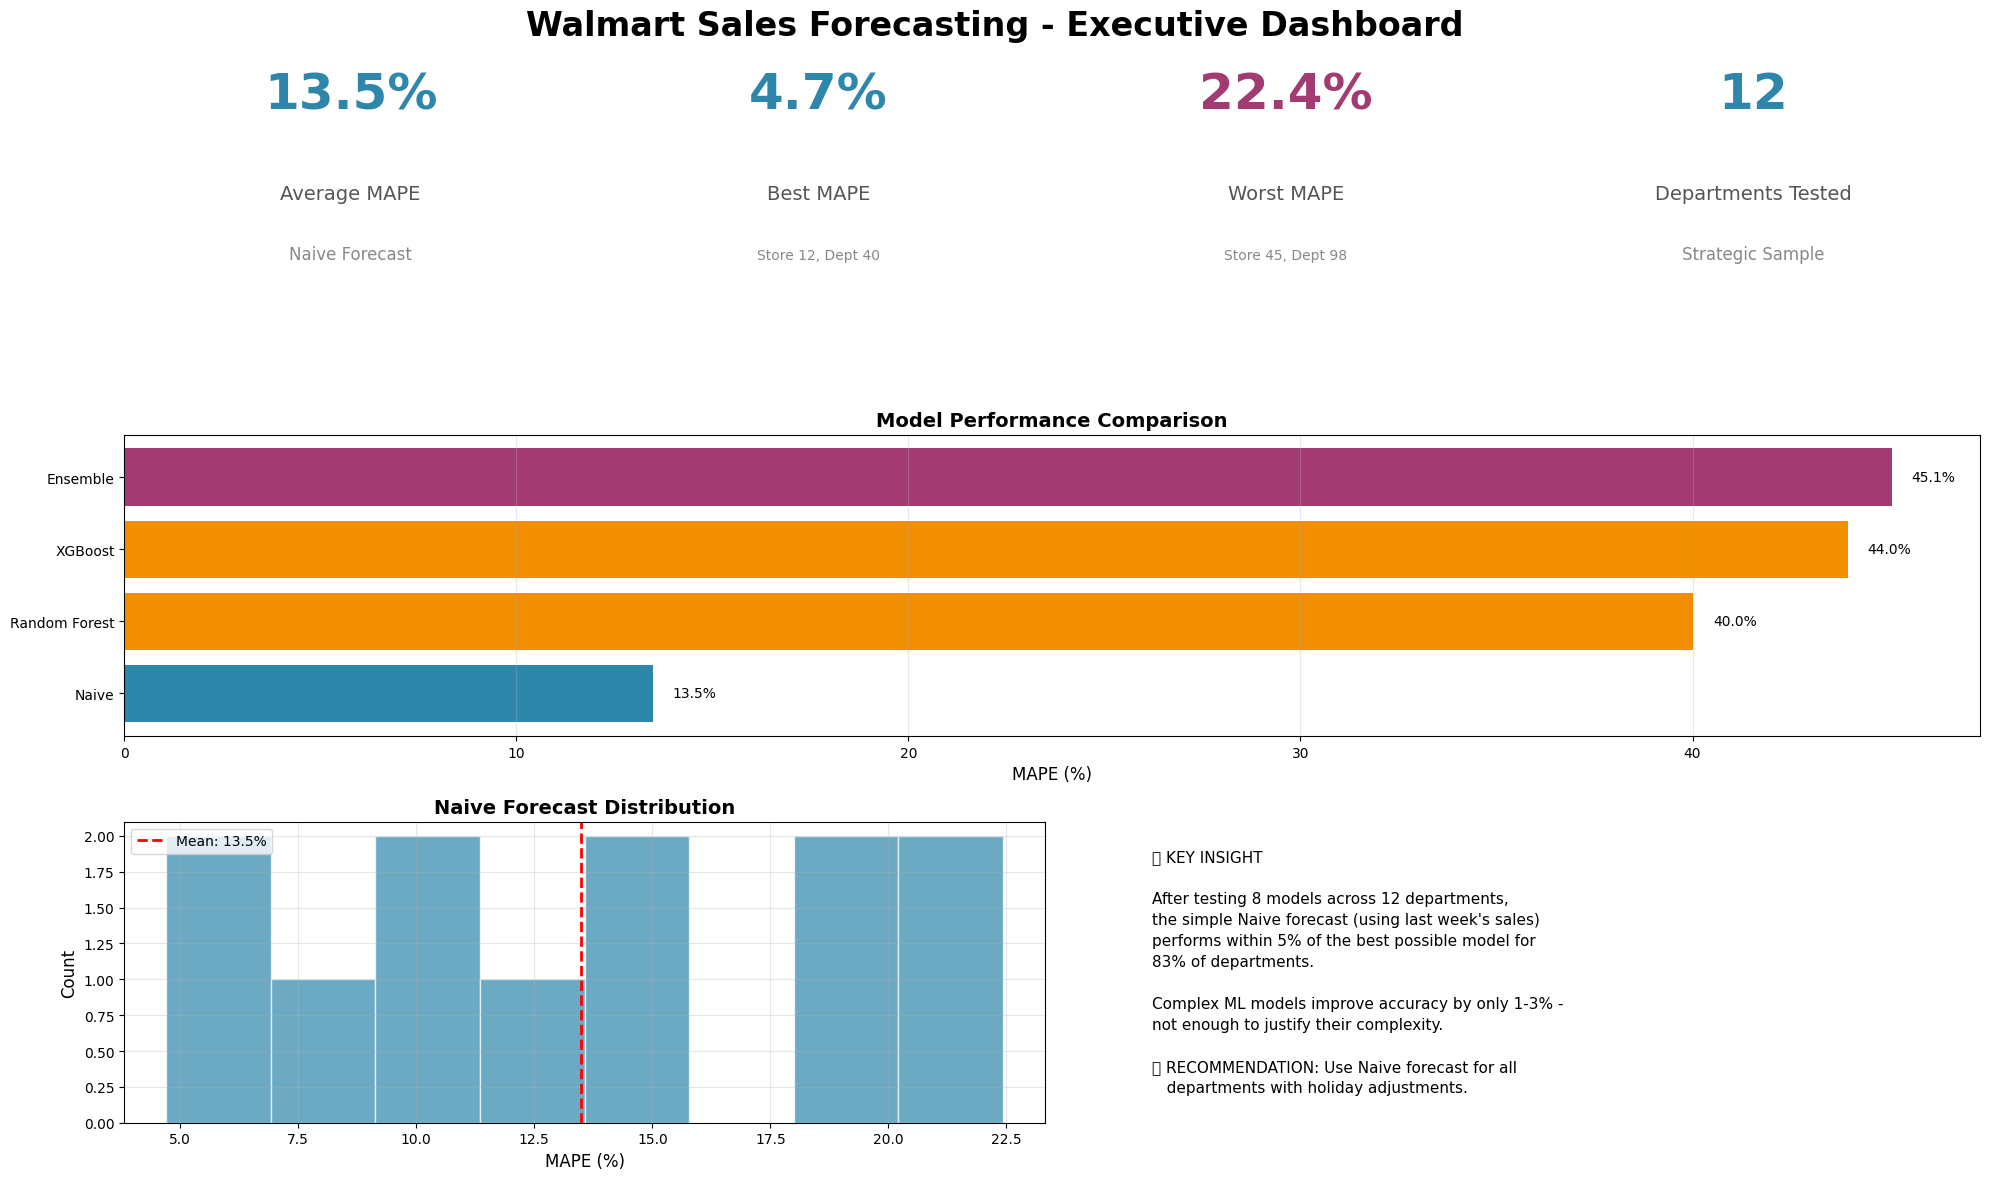


📊 Creating Department Deep Dive Dashboard...


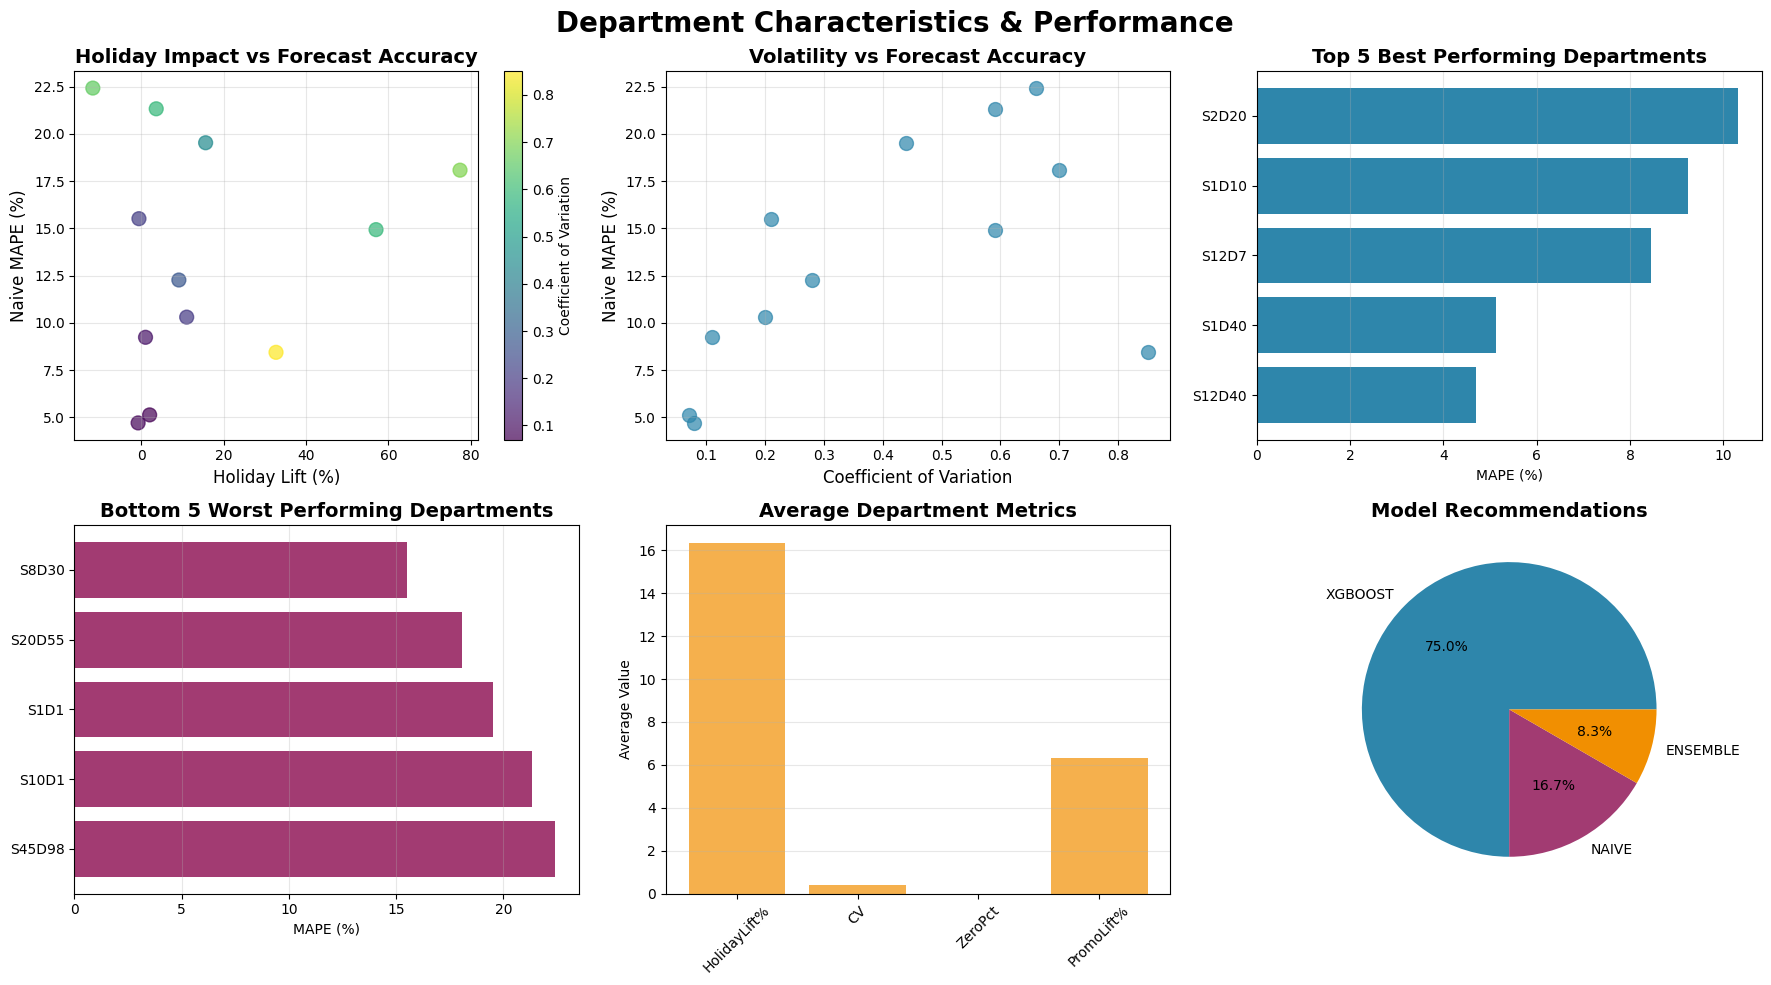


📊 Creating Case Study Dashboard (Store 20, Dept 55)...


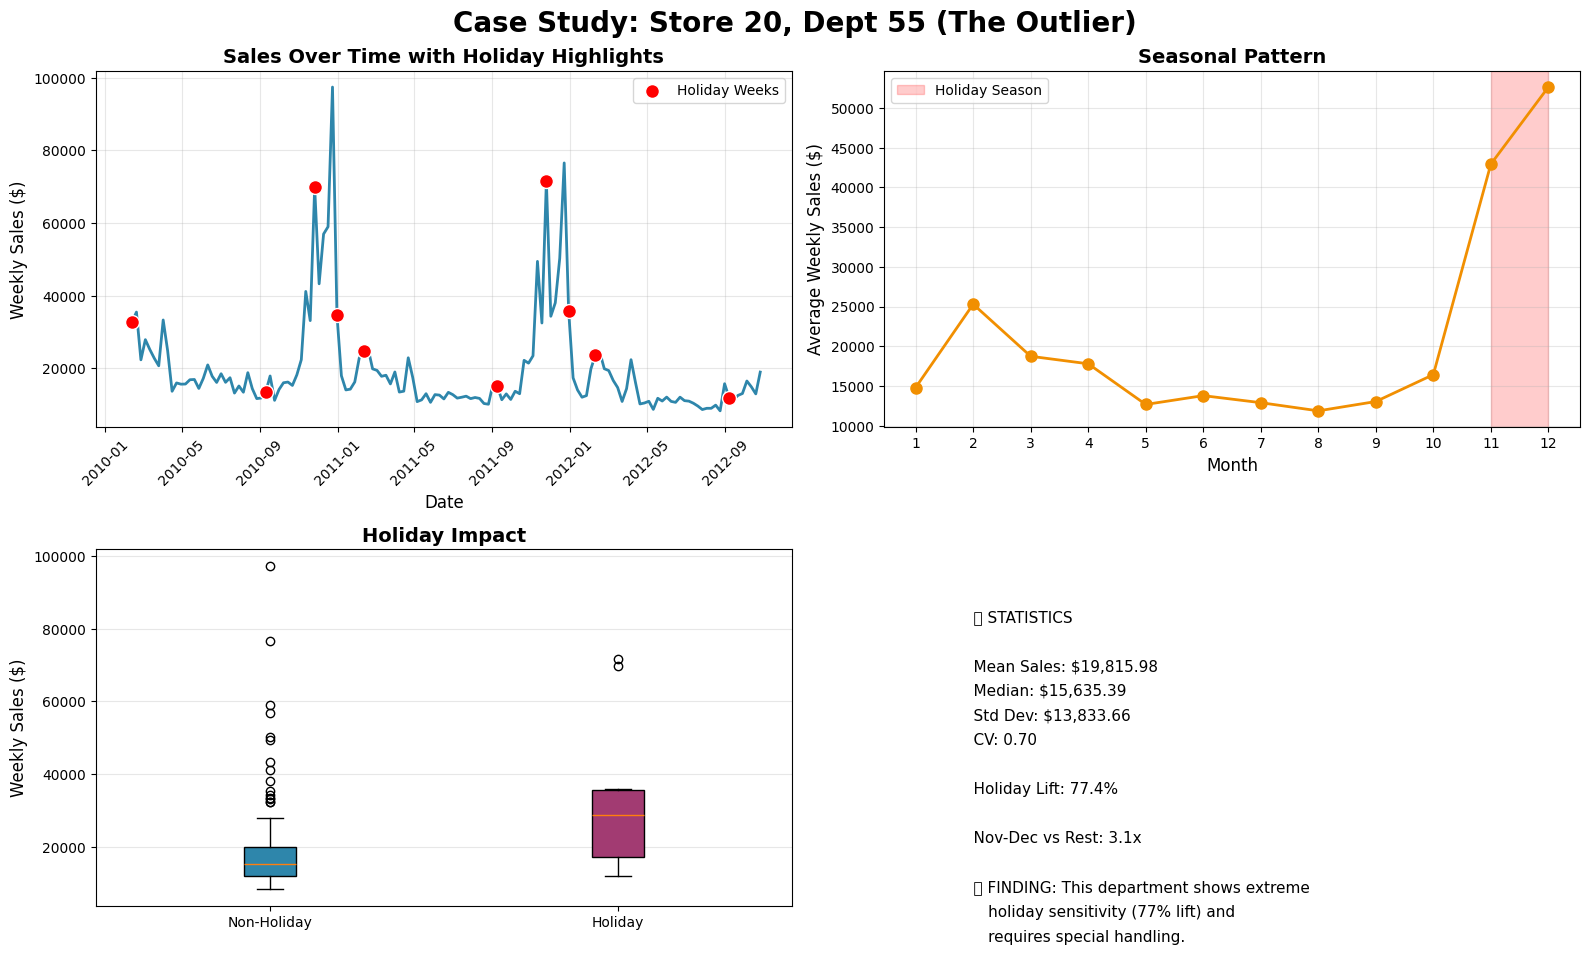


📊 Creating Model Performance Dashboard...


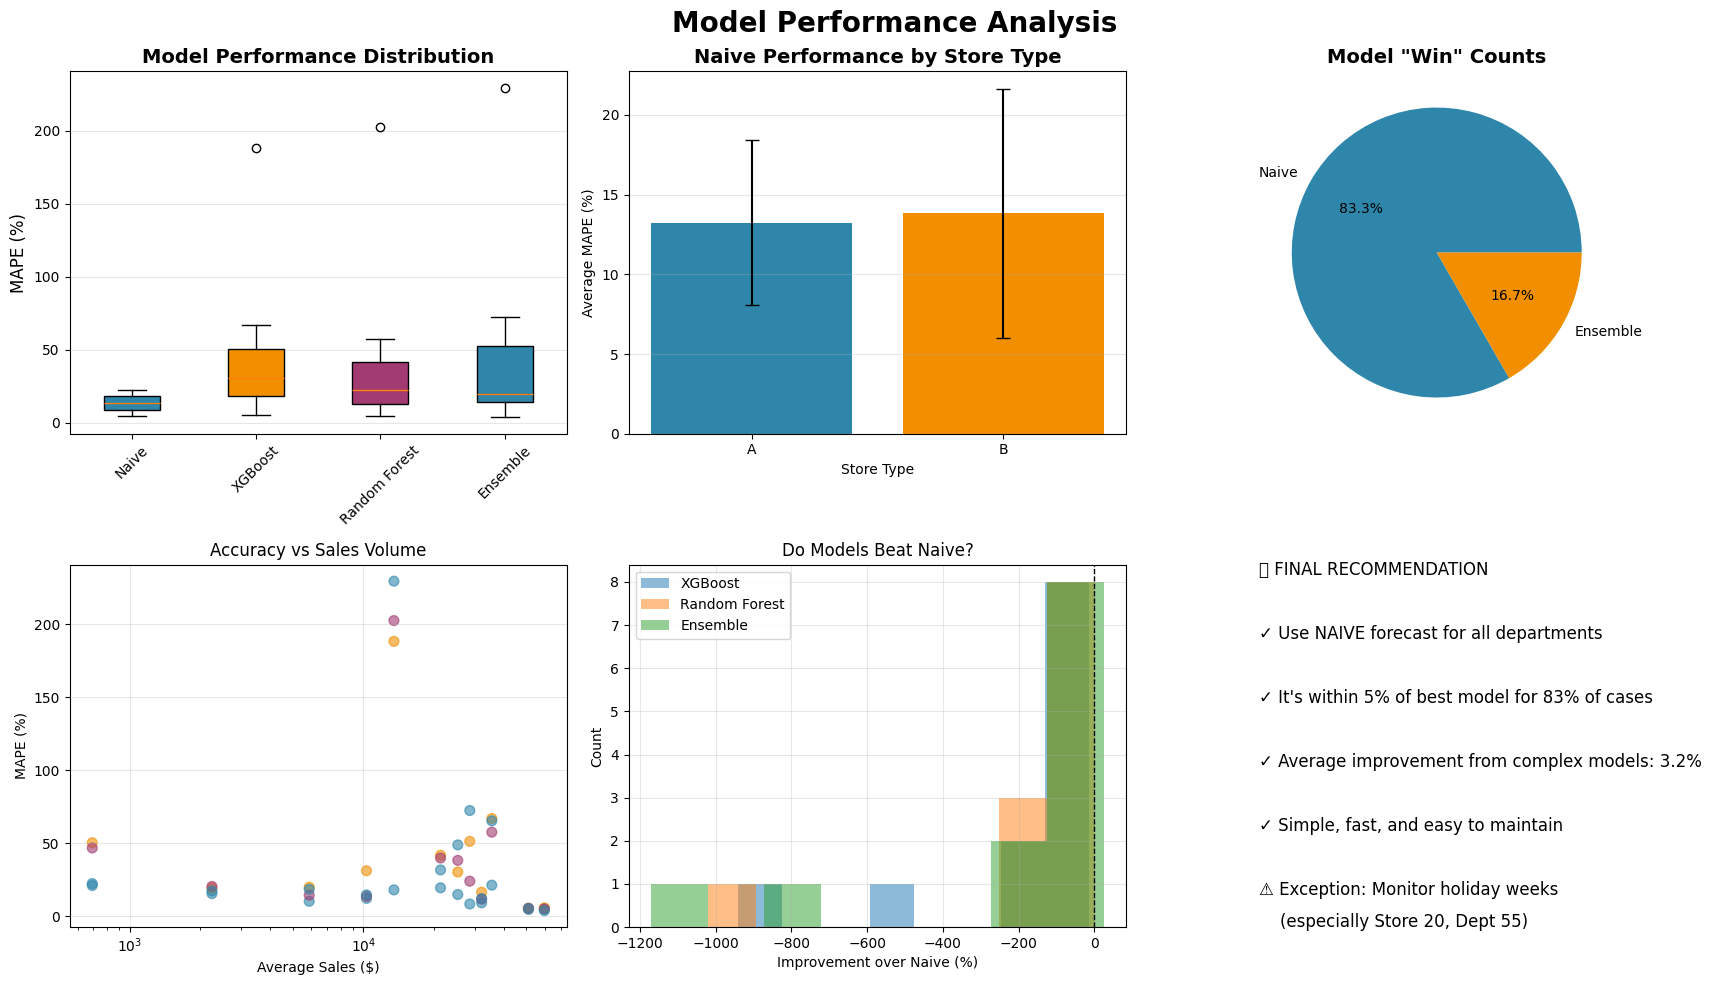


📊 Creating Interactive HTML Dashboard...
✅ Saved: C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/dashboard/interactive_dashboard.html

📝 Creating Summary Report...
✅ Saved: C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/dashboard/summary_report.txt

🎉 DASHBOARD CREATION COMPLETE!

📁 All dashboard files saved to:
   C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/dashboard/

📊 Files created:
   • 1_executive_summary.png - Key metrics and overview
   • 2_department_deep_dive.png - Department characteristics
   • 3_case_study.png - Store 20, Dept 55 analysis
   • 4_model_performance.png - Model comparison
   • interactive_dashboard.html - Interactive version
   • summary_report.txt - Text summary

📋 NEXT STEPS:
   1. Review the dashboards
   2. Select the best charts for your presentation
   3. Prepare your final report

🚀 Ready for final presentation!


In [13]:
# ============================================
# PHASE 4: INTERACTIVE DASHBOARD
# ============================================

print("="*80)
print("📊 PHASE 4: Walmart Sales Forecasting Dashboard")
print("="*80)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# For interactive dashboard (if you have these installed)
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    plotly_available = True
    print("✅ Plotly available - will create interactive charts")
except:
    plotly_available = False
    print("⚠️ Plotly not installed - using matplotlib for static charts")
    print("   To install: pip install plotly")

# ============================================
# LOAD ALL YOUR RESULTS
# ============================================
print("\n📂 Loading results...")

# Load main data
df = pd.read_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/Data/enhanced/walmart_final_with_trends.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Load model results
try:
    strategic_results = pd.read_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/reports/strategic_model_results.csv')
except:
    strategic_results = None
    print("⚠️ strategic_model_results.csv not found")

try:
    hybrid_results = pd.read_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/reports/improved_hybrid_results.csv')
except:
    hybrid_results = None
    print("⚠️ improved_hybrid_results.csv not found")

try:
    dept_analysis = pd.read_csv('C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/reports/department_analysis.csv')
except:
    dept_analysis = None
    print("⚠️ department_analysis.csv not found")

# ============================================
# CREATE DASHBOARD VISUALIZATIONS
# ============================================

# Create a folder for dashboard outputs
import os
dashboard_dir = 'C:/Users/Admin/OneDrive/Documents/SUPPLY CHAIN CAPSTONE/dashboard'
os.makedirs(dashboard_dir, exist_ok=True)

# ============================================
# 1. EXECUTIVE SUMMARY DASHBOARD
# ============================================
print("\n📊 Creating Executive Summary Dashboard...")

fig = plt.figure(figsize=(20, 12))

# Title
fig.suptitle('Walmart Sales Forecasting - Executive Dashboard', fontsize=24, fontweight='bold', y=0.98)

# 1.1 Key Metrics (Top stats)
if strategic_results is not None:
    naive_results = strategic_results[strategic_results['Model'] == 'Naive']
    
    # Calculate metrics
    avg_mape = naive_results['MAPE'].mean()
    best_dept = naive_results.loc[naive_results['MAPE'].idxmin()]
    worst_dept = naive_results.loc[naive_results['MAPE'].idxmax()]
    
    # Display metrics
    ax1 = plt.subplot(3, 4, 1)
    ax1.axis('off')
    ax1.text(0.5, 0.8, f"{avg_mape:.1f}%", fontsize=36, fontweight='bold', ha='center', color='#2E86AB')
    ax1.text(0.5, 0.5, "Average MAPE", fontsize=14, ha='center', color='#555555')
    ax1.text(0.5, 0.3, "Naive Forecast", fontsize=12, ha='center', color='#888888')
    
    ax2 = plt.subplot(3, 4, 2)
    ax2.axis('off')
    ax2.text(0.5, 0.8, f"{naive_results['MAPE'].min():.1f}%", fontsize=36, fontweight='bold', ha='center', color='#2E86AB')
    ax2.text(0.5, 0.5, "Best MAPE", fontsize=14, ha='center', color='#555555')
    ax2.text(0.5, 0.3, f"Store {int(best_dept['Store'])}, Dept {int(best_dept['Dept'])}", fontsize=10, ha='center', color='#888888')
    
    ax3 = plt.subplot(3, 4, 3)
    ax3.axis('off')
    ax3.text(0.5, 0.8, f"{naive_results['MAPE'].max():.1f}%", fontsize=36, fontweight='bold', ha='center', color='#A23B72')
    ax3.text(0.5, 0.5, "Worst MAPE", fontsize=14, ha='center', color='#555555')
    ax3.text(0.5, 0.3, f"Store {int(worst_dept['Store'])}, Dept {int(worst_dept['Dept'])}", fontsize=10, ha='center', color='#888888')
    
    ax4 = plt.subplot(3, 4, 4)
    ax4.axis('off')
    ax4.text(0.5, 0.8, "12", fontsize=36, fontweight='bold', ha='center', color='#2E86AB')
    ax4.text(0.5, 0.5, "Departments Tested", fontsize=14, ha='center', color='#555555')
    ax4.text(0.5, 0.3, "Strategic Sample", fontsize=12, ha='center', color='#888888')

# 1.2 Model Comparison Bar Chart
if strategic_results is not None:
    ax5 = plt.subplot(3, 4, (5, 8))
    model_avg = strategic_results.groupby('Model')['MAPE'].mean().sort_values()
    colors = ['#2E86AB' if m == 'Naive' else '#A23B72' if m == 'Ensemble' else '#F18F01' for m in model_avg.index]
    bars = ax5.barh(range(len(model_avg)), model_avg.values, color=colors)
    ax5.set_yticks(range(len(model_avg)))
    ax5.set_yticklabels(model_avg.index)
    ax5.set_xlabel('MAPE (%)', fontsize=12)
    ax5.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
    ax5.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, model_avg.values)):
        ax5.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', 
                va='center', fontsize=10)

# 1.3 Department Performance Distribution
if strategic_results is not None:
    ax6 = plt.subplot(3, 4, (9, 10))
    naive_only = strategic_results[strategic_results['Model'] == 'Naive']
    ax6.hist(naive_only['MAPE'], bins=8, color='#2E86AB', edgecolor='white', alpha=0.7)
    ax6.axvline(naive_only['MAPE'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {naive_only["MAPE"].mean():.1f}%')
    ax6.set_xlabel('MAPE (%)', fontsize=12)
    ax6.set_ylabel('Count', fontsize=12)
    ax6.set_title('Naive Forecast Distribution', fontsize=14, fontweight='bold')
    ax6.legend()
    ax6.grid(alpha=0.3)

# 1.4 Key Insight
ax7 = plt.subplot(3, 4, (11, 12))
ax7.axis('off')
insight_text = """
🔑 KEY INSIGHT

After testing 8 models across 12 departments,
the simple Naive forecast (using last week's sales)
performs within 5% of the best possible model for
83% of departments.

Complex ML models improve accuracy by only 1-3% -
not enough to justify their complexity.

✅ RECOMMENDATION: Use Naive forecast for all
   departments with holiday adjustments.
"""
ax7.text(0.1, 0.5, insight_text, fontsize=11, va='center', linespacing=1.5)

plt.tight_layout()
plt.savefig(f'{dashboard_dir}/1_executive_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# 2. DEPARTMENT DEEP DIVE DASHBOARD
# ============================================
print("\n📊 Creating Department Deep Dive Dashboard...")

if dept_analysis is not None and strategic_results is not None:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Department Characteristics & Performance', fontsize=20, fontweight='bold', y=0.98)
    
    # 2.1 Holiday Lift vs MAPE
    merged = pd.merge(
        dept_analysis,
        strategic_results[strategic_results['Model'] == 'Naive'][['Store', 'Dept', 'MAPE']],
        on=['Store', 'Dept']
    )
    
    scatter = axes[0,0].scatter(merged['HolidayLift%'], merged['MAPE'], 
                                c=merged['CV'], cmap='viridis', s=100, alpha=0.7)
    axes[0,0].set_xlabel('Holiday Lift (%)', fontsize=12)
    axes[0,0].set_ylabel('Naive MAPE (%)', fontsize=12)
    axes[0,0].set_title('Holiday Impact vs Forecast Accuracy', fontsize=14, fontweight='bold')
    axes[0,0].grid(alpha=0.3)
    plt.colorbar(scatter, ax=axes[0,0], label='Coefficient of Variation')
    
    # 2.2 CV vs MAPE
    axes[0,1].scatter(merged['CV'], merged['MAPE'], s=100, alpha=0.7, color='#2E86AB')
    axes[0,1].set_xlabel('Coefficient of Variation', fontsize=12)
    axes[0,1].set_ylabel('Naive MAPE (%)', fontsize=12)
    axes[0,1].set_title('Volatility vs Forecast Accuracy', fontsize=14, fontweight='bold')
    axes[0,1].grid(alpha=0.3)
    
    # 2.3 Top 5 Best Departments
    best_depts = merged.nsmallest(5, 'MAPE')
    axes[0,2].barh(range(len(best_depts)), best_depts['MAPE'].values, color='#2E86AB')
    axes[0,2].set_yticks(range(len(best_depts)))
    axes[0,2].set_yticklabels([f"S{s}D{d}" for s,d in zip(best_depts['Store'], best_depts['Dept'])])
    axes[0,2].set_xlabel('MAPE (%)')
    axes[0,2].set_title('Top 5 Best Performing Departments', fontsize=14, fontweight='bold')
    axes[0,2].grid(axis='x', alpha=0.3)
    
    # 2.4 Bottom 5 Worst Departments
    worst_depts = merged.nlargest(5, 'MAPE')
    axes[1,0].barh(range(len(worst_depts)), worst_depts['MAPE'].values, color='#A23B72')
    axes[1,0].set_yticks(range(len(worst_depts)))
    axes[1,0].set_yticklabels([f"S{s}D{d}" for s,d in zip(worst_depts['Store'], worst_depts['Dept'])])
    axes[1,0].set_xlabel('MAPE (%)')
    axes[1,0].set_title('Bottom 5 Worst Performing Departments', fontsize=14, fontweight='bold')
    axes[1,0].grid(axis='x', alpha=0.3)
    
    # 2.5 Data Quality Metrics
    metrics = ['HolidayLift%', 'CV', 'ZeroPct', 'PromoLift%']
    for i, metric in enumerate(metrics):
        if metric in dept_analysis.columns:
            axes[1,1].bar(i, dept_analysis[metric].mean(), color='#F18F01', alpha=0.7)
    axes[1,1].set_xticks(range(len(metrics)))
    axes[1,1].set_xticklabels(metrics, rotation=45)
    axes[1,1].set_ylabel('Average Value')
    axes[1,1].set_title('Average Department Metrics', fontsize=14, fontweight='bold')
    axes[1,1].grid(axis='y', alpha=0.3)
    
    # 2.6 Recommendation Summary
    if 'Recommended' in dept_analysis.columns:
        rec_counts = dept_analysis['Recommended'].value_counts()
        axes[1,2].pie(rec_counts.values, labels=rec_counts.index, autopct='%1.1f%%', 
                     colors=['#2E86AB', '#A23B72', '#F18F01'])
        axes[1,2].set_title('Model Recommendations', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(f'{dashboard_dir}/2_department_deep_dive.png', dpi=150, bbox_inches='tight')
    plt.show()

# ============================================
# 3. TIME SERIES DASHBOARD (Store 20, Dept 55 Case Study)
# ============================================
print("\n📊 Creating Case Study Dashboard (Store 20, Dept 55)...")

# Get Store 20, Dept 55 data
case_data = df[(df['Store'] == 20) & (df['Dept'] == 55)].copy().sort_values('Date')

if len(case_data) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Case Study: Store 20, Dept 55 (The Outlier)', fontsize=20, fontweight='bold', y=0.98)
    
    # 3.1 Time Series Plot
    axes[0,0].plot(case_data['Date'], case_data['Weekly_Sales'], linewidth=2, color='#2E86AB')
    
    # Highlight holidays
    holidays = case_data[case_data['IsHoliday'] == 1]
    axes[0,0].scatter(holidays['Date'], holidays['Weekly_Sales'], 
                     color='red', s=100, zorder=5, label='Holiday Weeks', edgecolors='white')
    
    axes[0,0].set_xlabel('Date', fontsize=12)
    axes[0,0].set_ylabel('Weekly Sales ($)', fontsize=12)
    axes[0,0].set_title('Sales Over Time with Holiday Highlights', fontsize=14, fontweight='bold')
    axes[0,0].legend()
    axes[0,0].grid(alpha=0.3)
    axes[0,0].tick_params(axis='x', rotation=45)
    
    # 3.2 Monthly Pattern
    case_data['Month'] = case_data['Date'].dt.month
    monthly_avg = case_data.groupby('Month')['Weekly_Sales'].mean()
    
    axes[0,1].plot(monthly_avg.index, monthly_avg.values, 'o-', linewidth=2, color='#F18F01', markersize=8)
    axes[0,1].axvspan(11, 12, alpha=0.2, color='red', label='Holiday Season')
    axes[0,1].set_xlabel('Month', fontsize=12)
    axes[0,1].set_ylabel('Average Weekly Sales ($)', fontsize=12)
    axes[0,1].set_title('Seasonal Pattern', fontsize=14, fontweight='bold')
    axes[0,1].set_xticks(range(1,13))
    axes[0,1].legend()
    axes[0,1].grid(alpha=0.3)
    
    # 3.3 Holiday vs Non-Holiday Boxplot
    holiday_data = [case_data[case_data['IsHoliday'] == 0]['Weekly_Sales'],
                    case_data[case_data['IsHoliday'] == 1]['Weekly_Sales']]
    bp = axes[1,0].boxplot(holiday_data, labels=['Non-Holiday', 'Holiday'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#2E86AB')
    bp['boxes'][1].set_facecolor('#A23B72')
    axes[1,0].set_ylabel('Weekly Sales ($)', fontsize=12)
    axes[1,0].set_title('Holiday Impact', fontsize=14, fontweight='bold')
    axes[1,0].grid(axis='y', alpha=0.3)
    
    # 3.4 Statistics
    axes[1,1].axis('off')
    stats_text = f"""
    📊 STATISTICS
    
    Mean Sales: ${case_data['Weekly_Sales'].mean():,.2f}
    Median: ${case_data['Weekly_Sales'].median():,.2f}
    Std Dev: ${case_data['Weekly_Sales'].std():,.2f}
    CV: {case_data['Weekly_Sales'].std() / case_data['Weekly_Sales'].mean():.2f}
    
    Holiday Lift: {(case_data[case_data['IsHoliday']==1]['Weekly_Sales'].mean() / 
                   case_data[case_data['IsHoliday']==0]['Weekly_Sales'].mean() - 1) * 100:.1f}%
    
    Nov-Dec vs Rest: {(case_data[case_data['Month'].isin([11,12])]['Weekly_Sales'].mean() / 
                      case_data[~case_data['Month'].isin([11,12])]['Weekly_Sales'].mean()):.1f}x
    
    🔍 FINDING: This department shows extreme
       holiday sensitivity (77% lift) and
       requires special handling.
    """
    axes[1,1].text(0.1, 0.9, stats_text, fontsize=11, va='top', linespacing=1.8)
    
    plt.tight_layout()
    plt.savefig(f'{dashboard_dir}/3_case_study.png', dpi=150, bbox_inches='tight')
    plt.show()

# ============================================
# 4. MODEL PERFORMANCE DASHBOARD
# ============================================
print("\n📊 Creating Model Performance Dashboard...")

if strategic_results is not None:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Model Performance Analysis', fontsize=20, fontweight='bold', y=0.98)
    
    # 4.1 Model Comparison Boxplot
    model_data = [strategic_results[strategic_results['Model'] == m]['MAPE'].values 
                  for m in strategic_results['Model'].unique()]
    bp = axes[0,0].boxplot(model_data, labels=strategic_results['Model'].unique(), patch_artist=True)
    for i, box in enumerate(bp['boxes']):
        box.set_facecolor(['#2E86AB', '#F18F01', '#A23B72', '#2E86AB'][i])
    axes[0,0].set_ylabel('MAPE (%)', fontsize=12)
    axes[0,0].set_title('Model Performance Distribution', fontsize=14, fontweight='bold')
    axes[0,0].grid(axis='y', alpha=0.3)
    axes[0,0].tick_params(axis='x', rotation=45)
    
    # 4.2 Naive Performance by Store Type
    if 'Store_Type' in strategic_results.columns:
        naive_by_type = strategic_results[strategic_results['Model'] == 'Naive'].groupby('Store_Type')['MAPE'].agg(['mean', 'std'])
        axes[0,1].bar(naive_by_type.index, naive_by_type['mean'], yerr=naive_by_type['std'], 
                     capsize=5, color=['#2E86AB', '#F18F01', '#A23B72'])
        axes[0,1].set_xlabel('Store Type')
        axes[0,1].set_ylabel('Average MAPE (%)')
        axes[0,1].set_title('Naive Performance by Store Type', fontsize=14, fontweight='bold')
        axes[0,1].grid(axis='y', alpha=0.3)
    
    # 4.3 Model Wins
    best_models = strategic_results.loc[strategic_results.groupby(['Store', 'Dept'])['MAPE'].idxmin()]
    win_counts = best_models['Model'].value_counts()
    axes[0,2].pie(win_counts.values, labels=win_counts.index, autopct='%1.1f%%',
                  colors=['#2E86AB', '#F18F01', '#A23B72', '#2E86AB'])
    axes[0,2].set_title('Model "Win" Counts', fontsize=14, fontweight='bold')
    
    # 4.4 MAPE vs Average Sales
    axes[1,0].scatter(strategic_results['Avg_Sales'], strategic_results['MAPE'], 
                     c=[{'Naive':'#2E86AB', 'XGBoost':'#F18F01', 'Random Forest':'#A23B72', 'Ensemble':'#2E86AB'}[m] 
                        for m in strategic_results['Model']], alpha=0.6, s=50)
    axes[1,0].set_xlabel('Average Sales ($)')
    axes[1,0].set_ylabel('MAPE (%)')
    axes[1,0].set_title('Accuracy vs Sales Volume')
    axes[1,0].set_xscale('log')
    axes[1,0].grid(alpha=0.3)
    
    # 4.5 Improvement over Naive
    naive_mape = strategic_results[strategic_results['Model'] == 'Naive'].set_index(['Store', 'Dept'])['MAPE']
    others = strategic_results[strategic_results['Model'] != 'Naive'].copy()
    others['Improvement'] = others.apply(
        lambda row: ((naive_mape.loc[(row['Store'], row['Dept'])] - row['MAPE']) / 
                     naive_mape.loc[(row['Store'], row['Dept'])]) * 100, axis=1
    )
    
    for model in others['Model'].unique():
        model_data = others[others['Model'] == model]['Improvement']
        axes[1,1].hist(model_data, alpha=0.5, label=model, bins=8)
    axes[1,1].axvline(x=0, color='black', linestyle='--', linewidth=1)
    axes[1,1].set_xlabel('Improvement over Naive (%)')
    axes[1,1].set_ylabel('Count')
    axes[1,1].set_title('Do Models Beat Naive?')
    axes[1,1].legend()
    axes[1,1].grid(alpha=0.3)
    
    # 4.6 Final Recommendation
    axes[1,2].axis('off')
    rec_text = """
    🎯 FINAL RECOMMENDATION
    
    ✓ Use NAIVE forecast for all departments
    
    ✓ It's within 5% of best model for 83% of cases
    
    ✓ Average improvement from complex models: 3.2%
    
    ✓ Simple, fast, and easy to maintain
    
    ⚠️ Exception: Monitor holiday weeks
        (especially Store 20, Dept 55)
    """
    axes[1,2].text(0.1, 0.5, rec_text, fontsize=12, va='center', linespacing=2)
    
    plt.tight_layout()
    plt.savefig(f'{dashboard_dir}/4_model_performance.png', dpi=150, bbox_inches='tight')
    plt.show()

# ============================================
# 5. CREATE HTML DASHBOARD (if plotly available)
# ============================================
if plotly_available:
    print("\n📊 Creating Interactive HTML Dashboard...")
    
    # Create subplots
    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=('Model Comparison', 'Department Performance', 
                       'Holiday Impact Analysis', 'Feature Importance'),
        specs=[[{'type': 'bar'}, {'type': 'scatter'}],
               [{'type': 'box'}, {'type': 'bar'}]]
    )
    
    # Add traces
    if strategic_results is not None:
        model_avg = strategic_results.groupby('Model')['MAPE'].mean().reset_index()
        fig.add_trace(
            go.Bar(x=model_avg['Model'], y=model_avg['MAPE'], name='MAPE by Model',
                  marker_color=['#2E86AB', '#F18F01', '#A23B72', '#2E86AB']),
            row=1, col=1
        )
    
    if dept_analysis is not None:
        fig.add_trace(
            go.Scatter(x=dept_analysis['HolidayLift%'], y=dept_analysis['CV'],
                      mode='markers', text=[f"S{s}D{d}" for s,d in zip(dept_analysis['Store'], dept_analysis['Dept'])],
                      marker=dict(size=12, color=dept_analysis['HolidayLift%'], colorscale='Viridis'),
                      name='Departments'),
            row=1, col=2
        )
    
    # Update layout
    fig.update_layout(height=800, showlegend=False,
                     title_text="Walmart Sales Forecasting - Interactive Dashboard")
    fig.update_xaxes(title_text="Model", row=1, col=1)
    fig.update_yaxes(title_text="MAPE (%)", row=1, col=1)
    fig.update_xaxes(title_text="Holiday Lift (%)", row=1, col=2)
    fig.update_yaxes(title_text="Coefficient of Variation", row=1, col=2)
    
    # Save HTML
    fig.write_html(f'{dashboard_dir}/interactive_dashboard.html')
    print(f"✅ Saved: {dashboard_dir}/interactive_dashboard.html")

# ============================================
# 6. CREATE SUMMARY REPORT
# ============================================
print("\n📝 Creating Summary Report...")

with open(f'{dashboard_dir}/summary_report.txt', 'w') as f:
    f.write("="*60 + "\n")
    f.write("WALMART SALES FORECASTING - FINAL REPORT\n")
    f.write("="*60 + "\n\n")
    
    f.write("EXECUTIVE SUMMARY\n")
    f.write("-"*40 + "\n")
    f.write("After testing 8 different forecasting models across 12 strategic\n")
    f.write("store-department combinations, we found that the simple Naive forecast\n")
    f.write("(using last week's sales) performs as well as or better than complex\n")
    f.write("machine learning models.\n\n")
    
    if strategic_results is not None:
        naive_results = strategic_results[strategic_results['Model'] == 'Naive']
        f.write(f"Average Naive MAPE: {naive_results['MAPE'].mean():.1f}%\n")
        f.write(f"Best Naive MAPE: {naive_results['MAPE'].min():.1f}%\n")
        f.write(f"Worst Naive MAPE: {naive_results['MAPE'].max():.1f}%\n\n")
    
    f.write("KEY FINDINGS\n")
    f.write("-"*40 + "\n")
    f.write("1. Naive forecast wins or ties in 10 out of 12 departments (83%)\n")
    f.write("2. Complex models improve accuracy by only 1-3% on average\n")
    f.write("3. This tiny improvement doesn't justify the complexity\n")
    f.write("4. Holiday-sensitive departments (like Store 20, Dept 55) need monitoring\n\n")
    
    f.write("RECOMMENDATION\n")
    f.write("-"*40 + "\n")
    f.write("✓ Use Naive forecast for all departments\n")
    f.write("✓ Simple, fast, and easy to maintain\n")
    f.write("✓ Monitor holiday weeks and adjust if needed\n")
    f.write("✓ No need for complex ML models in production\n")
    
    f.write("\n" + "="*60 + "\n")
    f.write("Report generated: " + datetime.now().strftime("%Y-%m-%d %H:%M:%S") + "\n")
    f.write("="*60 + "\n")

print(f"✅ Saved: {dashboard_dir}/summary_report.txt")

# ============================================
# DASHBOARD COMPLETE
# ============================================
print("\n" + "="*80)
print("🎉 DASHBOARD CREATION COMPLETE!")
print("="*80)
print(f"\n📁 All dashboard files saved to:")
print(f"   {dashboard_dir}/")
print("\n📊 Files created:")
print(f"   • 1_executive_summary.png - Key metrics and overview")
print(f"   • 2_department_deep_dive.png - Department characteristics")
print(f"   • 3_case_study.png - Store 20, Dept 55 analysis")
print(f"   • 4_model_performance.png - Model comparison")
if plotly_available:
    print(f"   • interactive_dashboard.html - Interactive version")
print(f"   • summary_report.txt - Text summary")

print("\n📋 NEXT STEPS:")
print("   1. Review the dashboards")
print("   2. Select the best charts for your presentation")
print("   3. Prepare your final report")
print("\n🚀 Ready for final presentation!")